# Exciton-bath kernel — step by step (Perfetto–Stefanucci 2016)

We reproduce, **one quantity at a time**, the incoherent-exciton framework of
PRB **94**, 245303 (2016) — which is the End-Matter formalism of the LLG /
exciton-bath paper (Garcia-Gaitan, Varela-Manjarres, Nikolić) — building toward the
exciton-induced **torque** and **damping** on the classical moments.

* **Regime:** incoherent, quasi-stationary excitons, vanishing polarization (relaxed regime).
* **Params:** our calibrated set (bright A exciton at 1.360 eV AFM, 15 meV redshift to FM).
* **Sector:** bright (symmetric) 2×2 sector; the full 4-channel diagonal basis (Eq. 13–14)
  is a later extension.

**Plan:** (1) $\Pi^R$ [Eq. 15] → (2) $\chi_\Phi=\Pi+\Pi D\Pi$ and $\chi^R$ [Eq. 18–19]
→ (3) $\chi^<$ with the occupation factor $F^n$ [Eq. 20–21] → (4) torque
$\mathbf B_e=i\,\mathrm{Tr}[G^<\hat X]$ and damping.

In [1]:
using LinearAlgebra
using Printf
using PyPlot
rc("font", family="serif"); rc("font", size=13)
rc("axes", labelsize=14, titlesize=14); rc("legend", fontsize=10)

# -----------------------------
# Setup — calibrated params (eV) + reused, validated machinery
# (same model as Static_D / ExcitonSpinSusceptibility)
# -----------------------------
L = 200
γ_c = 0.40; γ_v = 0.40
Δ_0 = 2.0
Jpd_v = 0.069; Jpd_c = 0.031
V_intra = 1.708; V_inter = 0.691
T = 0.001; μchem = Δ_0/2 #0.001
ηΩ = 0.02#3  ### w=4\gamma=1.6, L=200, eta = w/4L
ks = collect(range(-π, stop=π - 2π/L, length=L))

σ_0 = ComplexF64[1 0; 0 1]; σ_x = ComplexF64[0 1; 1 0]
ϵk(k, γ) = -2γ*cos(k)
H_valence(k, θ)    = (Jv=Jpd_v*cos(θ/2); -(ϵk(k,γ_v)+2γ_v+Jv)*σ_0 + Jv*σ_x)
H_conduction(k, θ) = (c=cos(θ/2); Jc=Jpd_c*c;
                      (ϵk(k,γ_c)+2γ_c+Δ_0+(Jpd_c+Jpd_v)*(1-c)+Jc)*σ_0 - Jc*σ_x)
fermi(E) = 1/(exp(clamp((E-μchem)/T,-60,60))+1)

# bright (symmetric) sector vertices and attraction
Γ_sector = [σ_0/√2, σ_x/√2]                       # (intralayer_s, CT_s)
V_s = Diagonal(ComplexF64[-V_intra, -V_inter])

# per-angle transition data: energies ΔE(k), occupation f_v-f_c, vertex weights w
function sector_data(θ; ks=ks)
    nt = 4*length(ks)
    ΔE=zeros(nt); occ=zeros(nt); w=zeros(ComplexF64,2,2,nt); t=0
    for k in ks
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k,θ)))
        m=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t+=1
            ΔE[t]=Fc.values[a]-Fv.values[b]
            occ[t]=fermi(Fv.values[b])-fermi(Fc.values[a])          # f_v - f_c
            for α in 1:2, β in 1:2; w[α,β,t]=m[α][a,b]*conj(m[β][a,b]); end
        end
    end
    return (; ΔE, occ, w, L=length(ks), c=cos(θ/2))
end

println("setup ready.")

setup ready.


## Step 1 — Retarded bubble $\Pi^R(\Omega)$  [Eq. 15]

$$
\Pi^{R,\lambda\lambda'}_{Q}(\Omega)=\frac{1}{N_k}\sum_k
\frac{f(\epsilon^{\lambda}_{c,k+Q})-f(\epsilon^{\lambda'}_{v,k})}
{\Omega-(\epsilon^{\lambda}_{c,k+Q}-\epsilon^{\lambda'}_{v,k})+i\eta}.
$$

Here at $Q=0$, in the bright ($s$) sector: a $2\times2$ matrix in the channels
(intralayer$_s$, CT$_s$). We use the convention $\mathrm{occ}=f_v-f_c$ (overall sign vs
the paper's $f_c-f_v$ is absorbed consistently in $D=(V^{-1}-\Pi)^{-1}$).

The **occupation factor $f_v-f_c=1$ in equilibrium** (all transitions interband) — this is
exactly where the incoherent exciton population will enter in Step 3. The spectral function
$-\mathrm{Im}\,\mathrm{Tr}\,\Pi^R$ is the joint continuum, with onset at $\min_k\Delta E(k)$;
the bright exciton sits **below** it (a bound pole of $D$, Step 2).

In [2]:
# Π^R(Ω) in the bright sector
Πs(d, Ω; η=ηΩ) = (P=zeros(ComplexF64,2,2);
    for t in eachindex(d.ΔE); @views P .+= (d.occ[t]/(Ω+1im*η-d.ΔE[t])).*d.w[:,:,t]; end;
    P./d.L)

θ = π/2
d = sector_data(θ)
onset = minimum(d.ΔE); top = maximum(d.ΔE)
@printf("θ/π = %.2f\n", θ/π)
@printf("continuum: onset min ΔE = %.4f eV,  top max ΔE = %.4f eV\n", onset, top)
@printf("occupation factor f_v-f_c: min=%.3f max=%.3f  (=1 ⇒ empty conduction, full valence)\n",
        minimum(d.occ), maximum(d.occ))

Ωs = collect(range(0.0, 6.0, length=601))
TrΠ  = [ tr(Πs(d,Ω)) for Ω in Ωs ]
AΠ   = -imag.(TrΠ)           # spectral function  -Im Tr Π^R
ReΠ  =  real.(TrΠ)

for Ω in (1.0, 1.5, onset, 2.1, 2.5)
    @printf("  Ω=%.4f : Tr Π^R = %+.4f %+.4fim\n", Ω, real(tr(Πs(d,Ω))), imag(tr(Πs(d,Ω))))
end

θ/π = 0.50
continuum: onset min ΔE = 2.0293 eV,  top max ΔE = 5.3707 eV
occupation factor f_v-f_c: min=1.000 max=1.000  (=1 ⇒ empty conduction, full valence)
  Ω=1.0000 : Tr Π^R = -0.9212 -0.0106im
  Ω=1.5000 : Tr Π^R = -1.3317 -0.0262im
  Ω=2.0293 : Tr Π^R = -4.2299 -2.9097im
  Ω=2.1000 : Tr Π^R = -2.2998 -2.3520im
  Ω=2.5000 : Tr Π^R = -0.0554 -1.9668im


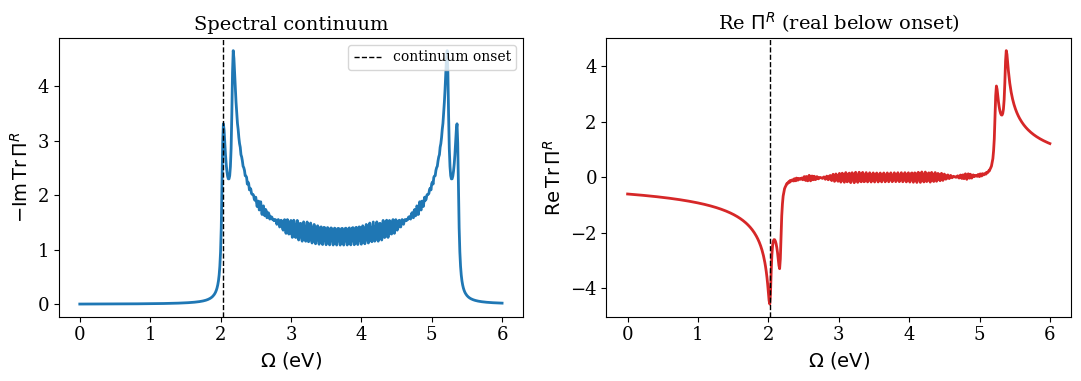

In [3]:
fig, ax = subplots(1, 2, figsize=(11.0, 4.0))
ax[1].plot(Ωs, AΠ, "-", lw=2, color="C0")
ax[1].axvline(onset, color="k", ls="--", lw=1, label="continuum onset")
ax[1].set_xlabel(L"\Omega\ \mathrm{(eV)}"); ax[1].set_ylabel(L"-\mathrm{Im}\,\mathrm{Tr}\,\Pi^R")
ax[1].set_title("Spectral continuum"); ax[1].legend()

ax[2].plot(Ωs, ReΠ, "-", lw=2, color="C3")
ax[2].axvline(onset, color="k", ls="--", lw=1)
ax[2].set_xlabel(L"\Omega\ \mathrm{(eV)}"); ax[2].set_ylabel(L"\mathrm{Re}\,\mathrm{Tr}\,\Pi^R")
ax[2].set_title(L"Re $\Pi^R$ (real below onset)")
tight_layout()

## Step 2 — Exciton susceptibility $\chi_\Phi=\Pi+\Pi\!\circ\!D\!\circ\!\Pi$  [Eq. 18-19]

The dressed exciton propagator and susceptibility,
$$
D=(V^{-1}-\Pi)^{-1},\qquad \chi_\Phi=\Pi+\Pi\,D\,\Pi .
$$
The poles of $\chi_\Phi$ are the exciton energies $\Omega_n$; the lowest (bright) one sits
**below the continuum onset** at $E_X$. In the pole (Lehmann) form of Eq. 19,
$\chi^R=i\sum_n Y_n\,s_n/(\omega-\Omega_n+i\eta)\,\bar Y_n$. Here we (i) locate the pole at
$E_X$ and (ii) check that its residue equals the single bright-mode projection
$Z\,(\Pi X)(\Pi X)^\dagger$ — i.e. one term $n$ dominates, with $\Omega_n=E_X$, $Y_n\propto\Pi X$.

In [4]:
# dressed propagator D and susceptibility χ_Φ = Π + Π D Π  (reuses d, Πs from Step 1)
Vinv_s = Matrix(inv(V_s))
∂Πs(d, Ω) = (P=zeros(ComplexF64,2,2);
    for t in eachindex(d.ΔE); @views P .+= (-d.occ[t]/(Ω-d.ΔE[t])^2).*d.w[:,:,t]; end; P./d.L)
D_s(d, Ω; η=ηΩ) = inv(Vinv_s - Πs(d, Ω; η=η))
χΦ(d, Ω; η=ηΩ) = (P=Πs(d,Ω;η=η); P + P*D_s(d,Ω;η=η)*P)

# bright exciton mode: E_X (λ_max of V^{-1}-Π crosses 0), eigenvector X, residue Z
function exciton_mode(d)
    cont_min = minimum(d.ΔE)
    λmax(Ω) = maximum(real(eigvals(Hermitian(Vinv_s - Πs(d,Ω)))))
    lo, hi = 0.0, cont_min - 1e-9
    for _ in 1:100; mid=(lo+hi)/2; (λmax(mid)<0) ? (lo=mid) : (hi=mid); end
    EX = (lo+hi)/2
    F = eigen(Hermitian(Vinv_s - Πs(d,EX))); X = F.vectors[:, argmax(real(F.values))]
    X = X .* exp(-1im*angle(X[1])); Z = -1/real(X'*∂Πs(d,EX)*X)
    return (; EX, X, Z, cont_min)
end

m = exciton_mode(d)
@printf("bright exciton  E_X = %.4f eV   (below continuum onset %.4f)   Z = %.3f\n",
        m.EX, m.cont_min, m.Z)

println("\n Ω(eV)     -Im Tr χ_Φ   (pole at E_X)")
for Ω in range(m.EX-0.006, m.EX+0.006, length=7)
    @printf("  %.4f    %+.3e\n", Ω, -2*imag(tr(χΦ(d,Ω))))
end

# residue check: (Ω-E_X+iη)χ_Φ|_{Ω=E_X} = iη·χ_Φ  ≈  Z (Π X)(Π X)†  (single bright mode)
res  = 1im*ηΩ .* χΦ(d, m.EX)
PX   = Πs(d, m.EX) * m.X
proj = m.Z .* (PX*PX')
@printf("\nresidue check  Re Tr(res)/Tr(Z(ΠX)(ΠX)†) = %.4f   (should be ≈ 1)\n",
        real(tr(res)/tr(proj)))

bright exciton  E_X = 1.3525 eV   (below continuum onset 2.0293)   Z = 2.103

 Ω(eV)     -Im Tr χ_Φ   (pole at E_X)
  1.3465    +6.744e+01
  1.3485    +7.044e+01
  1.3505    +7.226e+01
  1.3525    +7.269e+01
  1.3545    +7.169e+01
  1.3565    +6.937e+01
  1.3585    +6.598e+01

residue check  Re Tr(res)/Tr(Z(ΠX)(ΠX)†) = 1.0009   (should be ≈ 1)


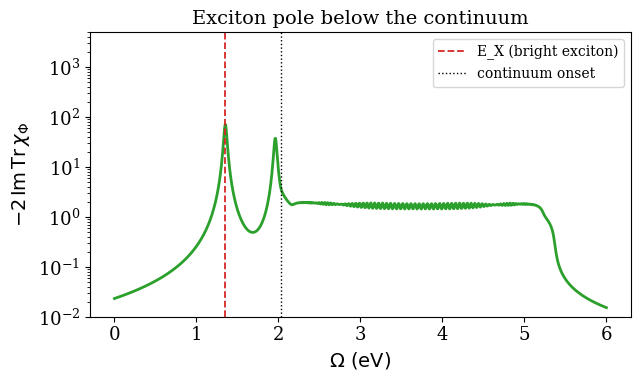

In [5]:
Ωs2 = collect(range(0.0, 6.0, length=801))
Aχ  = [ -2*imag(tr(χΦ(d,Ω))) for Ω in Ωs2 ]
fig, ax = subplots(figsize=(6.6, 4.0))
ax.plot(Ωs2, Aχ, "-", lw=2, color="C2")
ax.axvline(m.EX, color="C3", ls="--", lw=1.3, label="E_X (bright exciton)")
ax.axvline(m.cont_min, color="k", ls=":", lw=1, label="continuum onset")
ax.set_yscale("log"); ax.set_ylim(1e-2, 5e3)
ax.set_xlabel(L"\Omega\ \mathrm{(eV)}"); ax.set_ylabel(L"-2\,\mathrm{Im}\,\mathrm{Tr}\,\chi_\Phi")
ax.set_title("Exciton pole below the continuum"); ax.legend()
tight_layout()

## Step 3 — Excited occupations & phase-space filling  [Eq. 66]

The incoherent excited state (relaxed regime) is set by **Fermi-Dirac with a hot temperature
$T$ and SEPARATE quasi-chemical-potentials** for electrons ($\mu_c$) and holes ($\mu_v$):
$$
f_c(k)=\mathrm{FD}(\epsilon_c(k);\mu_c,T),\qquad f_v(k)=\mathrm{FD}(\epsilon_v(k);\mu_v,T).
$$
The bubble occupation factor becomes $\mathrm{occ}=f_v-f_c<1$ (it was $1$ in equilibrium)
→ **phase-space filling / bleaching**. We use a symmetric quasi-Fermi splitting
$\mu_c=\tfrac{\Delta_0}{2}+s,\ \mu_v=\tfrac{\Delta_0}{2}-s$ (knob $s$) and report the carrier
density $n_c=\frac{1}{N_k}\sum_{k,a}f_c^a(k)$.

Expected: as $n_c\to0$ we recover equilibrium ($E_X=1.3521$, occ $=1$); as $n_c$ grows the
exciton **binding weakens (E_X blueshifts)** — the density effect on the BSE (matches 2016:
the bound state departs from the equilibrium BSE as $n_c$ grows). This modified $\Pi(f_c,f_v)$
is the input for the lesser $\chi^<$ and the population weight $Z_X(n_c)$ (Step 4).

In [6]:
FD(E, μ, Tx) = 1/(exp(clamp((E-μ)/Tx,-60,60))+1)

# excited transition data: FD occupations with separate μ_c, μ_v, hot T  (Eq. 66)
function sector_data_exc(θ; μc, μv, Tx, ks=ks)
    nt=4*length(ks); ΔE=zeros(nt); occ=zeros(nt); w=zeros(ComplexF64,2,2,nt)
    nc=0.0; nh=0.0
    t=0
    for k in ks
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k,θ)))
        mα=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t+=1
            ΔE[t]=Fc.values[a]-Fv.values[b]
            occ[t]=FD(Fv.values[b],μv,Tx) - FD(Fc.values[a],μc,Tx)      # f_v - f_c
            for α in 1:2, β in 1:2; w[α,β,t]=mα[α][a,b]*conj(mα[β][a,b]); end
        end
        for a in 1:2; nc += FD(Fc.values[a],μc,Tx); end
        for b in 1:2; nh += 1 - FD(Fv.values[b],μv,Tx); end
    end
    return (; ΔE, occ, w, L=length(ks), c=cos(θ/2), nc=nc/length(ks), nh=nh/length(ks))
end

Tx = 0.10; midgap = Δ_0/2
d_eq = sector_data_exc(θ; μc=midgap, μv=midgap, Tx=Tx)     # s=0 → equilibrium
EXeq = exciton_mode(d_eq).EX
@printf("equilibrium (s=0): E_X = %.4f eV,  n_c = %.1e\n\n", EXeq, d_eq.nc)

println("   s     n_c        n_h        occ_min   E_X(eV)   ΔE_X(meV)   Z")
for s in (0.0, 0.3, 0.5, 0.7, 0.9)
    d = sector_data_exc(θ; μc=midgap+s, μv=midgap-s, Tx=Tx); mm = exciton_mode(d)
    @printf("  %.2f  %.3e  %.3e   %+.3f   %.4f   %+7.2f    %.3f\n",
            s, d.nc, d.nh, minimum(d.occ), mm.EX, 1e3*(mm.EX-EXeq), mm.Z)
end

equilibrium (s=0): E_X = 1.3525 eV,  n_c = 8.0e-06

   s     n_c        n_h        occ_min   E_X(eV)   ΔE_X(meV)   Z
  0.00  7.992e-06  8.966e-06   +1.000   1.3525     +0.00    2.103
  0.30  1.605e-04  1.800e-04   +0.998   1.3529     +0.44    2.102
  0.50  1.183e-03  1.325e-03   +0.988   1.3559     +3.37    2.098
  0.70  8.574e-03  9.558e-03   +0.917   1.3771    +24.57    2.067
  0.90  5.580e-02  6.041e-02   +0.516   1.5138   +161.27    1.865


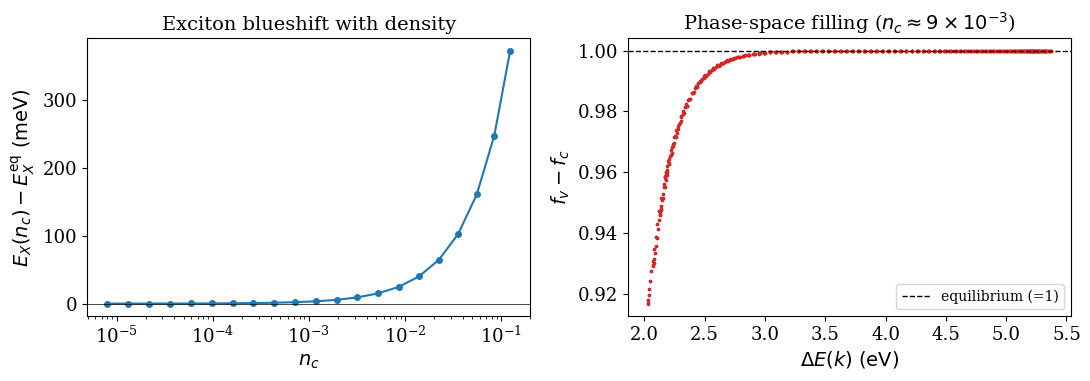

In [7]:
# E_X vs density, and the phase-space-filling occupation factor
ss = collect(range(0.0, 1.0, length=21))
ncs = Float64[]; EXs = Float64[]
for s in ss
    d = sector_data_exc(θ; μc=midgap+s, μv=midgap-s, Tx=Tx); mm = exciton_mode(d)
    push!(ncs, d.nc); push!(EXs, mm.EX)
end
d_rep = sector_data_exc(θ; μc=midgap+0.7, μv=midgap-0.7, Tx=Tx)   # representative excited state

fig, ax = subplots(1, 2, figsize=(11.0, 4.0))
ax[1].plot(ncs, 1e3 .*(EXs .- EXeq), "o-", lw=1.5, ms=4, color="C0")
ax[1].set_xscale("log"); ax[1].set_xlabel(L"n_c"); ax[1].set_ylabel(L"E_X(n_c)-E_X^{\mathrm{eq}}\ \mathrm{(meV)}")
ax[1].set_title("Exciton blueshift with density"); ax[1].axhline(0, color="k", lw=0.5)

ax[2].plot(d_rep.ΔE, d_rep.occ, ".", ms=3, color="C3")
ax[2].axhline(1.0, color="k", ls="--", lw=1, label="equilibrium (=1)")
ax[2].set_xlabel(L"\Delta E(k)\ \mathrm{(eV)}"); ax[2].set_ylabel(L"f_v-f_c")
ax[2].set_title(L"Phase-space filling ($n_c\approx9\times10^{-3}$)"); ax[2].legend()
tight_layout()

## Step 4 — Lesser $\chi^<$ and the exciton population weight $F^{\rm bright}$  [Eq. 20-21, 37]

The retarded pole (Steps 2-3) gives the exciton *energy*; the **population** lives in the
lesser component,
$$
\chi^<_Q(\omega)=2\pi\sum_n F^n_Q\,Y^n_Q\,\delta(\omega-\Omega^n_Q)\,\bar Y^n_Q,\qquad
F^n=\sum_I |Y^n_I|^2\,\frac{f_c^I\,(1-f_v^I)}{(f_v^I-f_c^I)^2}.
$$
This needs the **$k$-resolved exciton wavefunction $Y(k)$**, from the 2016 transition-basis BSE
(Eq. 28-32):
$$
(\sigma_z\,\omega-\tilde K)\tilde Y=\lambda\,\sigma_z\tilde Y,\quad
\tilde K=\sqrt{|f|}\,K\,\sqrt{|f|},\quad \sigma_z=\mathrm{sign}(f_v-f_c),\quad Y=\sqrt{|f|}\,\tilde Y.
$$
For our **neutral** excitation there is no inversion, so $\sigma_z=+1$ (standard problem).

$F^{\rm bright}$ is the exciton **population** weight (the code variable is still named `Zx`); in the
2026 unified language it estimates the incoherent population $N^{\rm inc}_{\lambda Q}$ (arXiv:2601.16786,
Eq. 7). Since $F\propto f_c(1-f_v)$ = (electron occ)×(hole occ), for **neutral photoexcitation**
($n_c=n_h$, a pulse creating e-h pairs) $F^{\rm bright}\propto n_c\,n_h\propto n^2$ — the
**mass-action law** $n_X\sim n_e n_h$.

> **Naming note — this is *not* the $Z_X$ of 2016 Fig. 5.** The paper's $Z_X$ is the **spectral
> residue** of the exciton peak in $A(\omega)$ (weight the bare electron transfers to the bound qp,
> $\int^{\epsilon_{c0}}A\,d\omega/2\pi$), which grows roughly **linearly** with $n_c$. The quantity
> computed here is the Eq.-37 **population** weight $F^\lambda$, which scales as $n^2$ (mass action).
> The two only coincide in the single-exciton limit, where both equal $|Y_0|^2$.


In [8]:
Vα = [V_intra, V_inter]

# excited transitions in the full basis I=(a,b,k), with per-transition f_c, f_v
function transitions_exc(θ; μc, μv, Tx, ks=ks)
    nT=4*length(ks); ΔE=zeros(nT); fc=zeros(nT); fv=zeros(nT); M=zeros(ComplexF64,2,nT)
    kidx=zeros(Int,nT); t=0; nc=0.0; nh=0.0
    for (ik,k) in enumerate(ks)
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k,θ)))
        mα=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t+=1; ΔE[t]=Fc.values[a]-Fv.values[b]; kidx[t]=ik
            fc[t]=FD(Fc.values[a],μc,Tx); fv[t]=FD(Fv.values[b],μv,Tx)
            for α in 1:2; M[α,t]=mα[α][a,b]; end
        end
        for a in 1:2; nc += FD(Fc.values[a],μc,Tx); end
        for b in 1:2; nh += 1 - FD(Fv.values[b],μv,Tx); end
    end
    return (; ΔE, fc, fv, M, kidx, nc=nc/length(ks), nh=nh/length(ks))
end

# 2016 transition-basis BSE → bright E_X, wavefunction |Y(k)|², weight Z_X = F^bright
function bright_mode_exc(θ; μc, μv, Tx)
    d = transitions_exc(θ; μc=μc, μv=μv, Tx=Tx)
    fI = d.fv .- d.fc; onset = minimum(d.ΔE); sf = sqrt.(abs.(fI)); σz = sign.(fI)
    Kt = zeros(ComplexF64, length(fI), length(fI))
    for α in 1:2; u = sf .* d.M[α,:]; Kt .+= (Vα[α]/L).*(u*u'); end
    Hp = Diagonal(ComplexF64.(d.ΔE)) .- Diagonal(ComplexF64.(σz))*Kt   # (ω-σz K̃)Ỹ=λỸ
    F = eigen(Hp); ev = F.values
    below = findall(x-> real(x)<onset-1e-6 && abs(imag(x))<1e-5, ev)
    isempty(below) && return (; EX=NaN, Zx=NaN, nc=d.nc, nh=d.nh, Yk2=zeros(length(ks)))
    j = below[argmin(real.(ev[below]))]; Ỹ = F.vectors[:,j]
    Ỹ ./= sqrt(abs(sum(σz .* abs2.(Ỹ))))               # metric-normalize  Ỹ†σz Ỹ = ±1
    Y = sf .* Ỹ
    msk = abs.(fI) .> 1e-4                              # S^q subspace (avoid 1/f_I² blowup)
    Zx = real(sum(msk[i] ? abs2(Y[i])*d.fc[i]*(1-d.fv[i])/fI[i]^2 : 0.0 for i in eachindex(fI)))
    Yk2 = zeros(length(ks)); for i in eachindex(fI); Yk2[d.kidx[i]] += abs2(Y[i]); end
    return (; EX=real(ev[j]), Zx, nc=d.nc, nh=d.nh, Yk2)
end

Tx = 0.10; mid = Δ_0/2
r0 = bright_mode_exc(θ; μc=mid, μv=mid, Tx=Tx)
@printf("equilibrium check: E_X = %.4f eV,  n_c = %.1e,  Z_X = %.2e (≈0, empty)\n\n",
        r0.EX, r0.nc, r0.Zx)

println("   s      n_c        E_X       Z_X          slope d(logZ)/d(log n_c)")
prev = nothing
for s in (0.3, 0.5, 0.7, 0.9)
    r = bright_mode_exc(θ; μc=mid+s, μv=mid-s, Tx=Tx)
    sl = prev===nothing ? NaN : (log(r.Zx)-log(prev[2]))/(log(r.nc)-log(prev[1]))
    @printf("  %.2f   %.3e   %.4f   %.4e   %s\n", s, r.nc, r.EX, r.Zx,
            isnan(sl) ? "-" : @sprintf("%.2f", sl))
    global prev = (r.nc, r.Zx)
end

equilibrium check: E_X = 1.3521 eV,  n_c = 8.0e-06,  Z_X = 3.87e-10 (≈0, empty)

   s      n_c        E_X       Z_X          slope d(logZ)/d(log n_c)
  0.30   1.605e-04   1.3525   1.5600e-07   -
  0.50   1.183e-03   1.3555   8.4956e-06   2.00
  0.70   8.574e-03   1.3766   4.5566e-04   2.01
  0.90   5.580e-02   1.5133   2.3074e-02   2.10


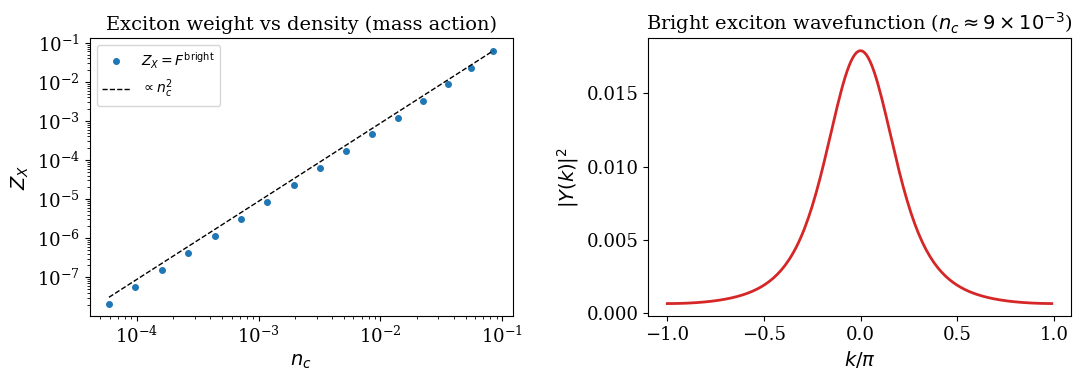

In [9]:
# Z_X vs density (mass-action ∝ n²) and the bright exciton wavefunction Y(k)
ss4 = collect(range(0.2, 0.95, length=16))
ncs4 = Float64[]; Zxs = Float64[]
for s in ss4
    r = bright_mode_exc(θ; μc=mid+s, μv=mid-s, Tx=Tx)
    push!(ncs4, r.nc); push!(Zxs, r.Zx)
end
r_rep = bright_mode_exc(θ; μc=mid+0.7, μv=mid-0.7, Tx=Tx)

fig, ax = subplots(1, 2, figsize=(11.0, 4.0))
ax[1].loglog(ncs4, Zxs, "o", ms=4, color="C0", label=L"Z_X=F^{\mathrm{bright}}")
ax[1].loglog(ncs4, Zxs[end].*(ncs4./ncs4[end]).^2, "k--", lw=1, label=L"\propto n_c^2")
ax[1].set_xlabel(L"n_c"); ax[1].set_ylabel(L"Z_X")
ax[1].set_title("Exciton weight vs density (mass action)"); ax[1].legend()

ax[2].plot(ks./π, r_rep.Yk2, "-", lw=2, color="C3")
ax[2].set_xlabel(L"k/\pi"); ax[2].set_ylabel(L"|Y(k)|^2")
ax[2].set_title(L"Bright exciton wavefunction ($n_c\approx9\times10^{-3}$)")
tight_layout()

### Understanding the $Y(k)$ spectrum

The transition-basis BSE is **800-dimensional** ($4$ band-pairs $\times\,200\ k$) → 800 eigenpairs
$(\Omega_\lambda, Y_\lambda(k))$. The **rank-2 separable kernel** (the 2 channels: intralayer, CT)
binds **at most 2 states** below the continuum onset:
- **bright exciton** ($E_X=1.352$ eV, intralayer-dominated),
- **CT exciton** ($1.962$ eV, interlayer-dominated).

The other $\sim798$ are **continuum** (unbound e-h) states filling $[2.03, 5.37]$ eV. Bound states
have a **smooth $Y(k)$ spread over the BZ** (peaked at $k=0$ → delocalized in real space);
continuum states are **single-$k$ spikes** (extended e-h at fixed $k$). Only the lowest bound
(bright) enters $Z_X$.

800 eigenvalues ; 2 bound below onset 2.029 eV : 1.3521 1.9615 eV  (bright, CT)


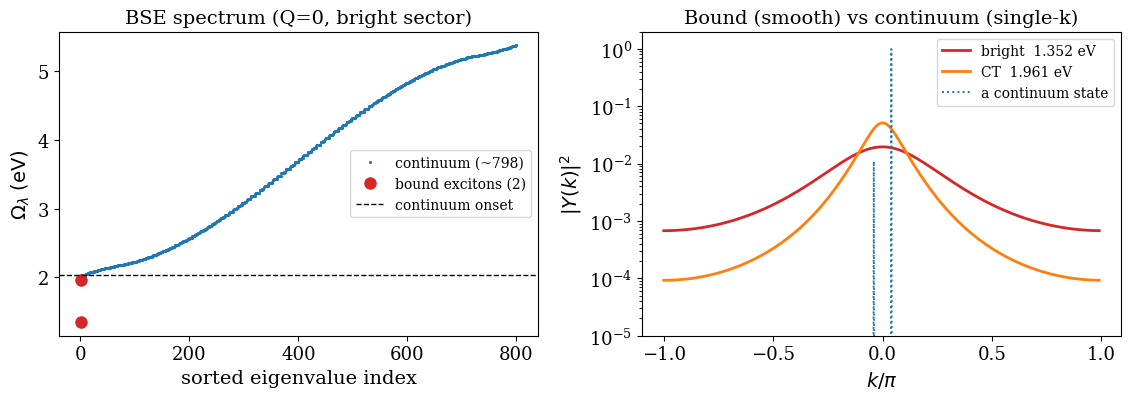

In [10]:
# Eigenvalue spectrum and the Y(k) of the bound excitons (near-equilibrium, for clarity)
function full_bse(θ; μc, μv, Tx)
    d = transitions_exc(θ; μc=μc, μv=μv, Tx=Tx)
    fI = d.fv .- d.fc; onset = minimum(d.ΔE); sf = sqrt.(abs.(fI)); σz = sign.(fI)
    Kt = zeros(ComplexF64, length(fI), length(fI))
    for α in 1:2; u = sf .* d.M[α,:]; Kt .+= (Vα[α]/L).*(u*u'); end
    H = Diagonal(ComplexF64.(d.ΔE)) .- Diagonal(ComplexF64.(σz))*Kt
    F = eigen(H); ev = real.(F.values); p = sortperm(ev)
    return ev[p], F.vectors[:,p], onset, sf, d.kidx
end
Yk2(col, Vmat, sf, kidx) = (Y = sf .* Vmat[:,col]; Y ./= sqrt(sum(abs2,Y));
    y = zeros(length(ks)); for i in eachindex(sf); y[kidx[i]] += abs2(Y[i]); end; y)

ev, Vmat, onset4, sf4, kidx4 = full_bse(θ; μc=Δ_0/2, μv=Δ_0/2, Tx=0.10)
nb = count(<(onset4-1e-6), ev)
@printf("%d eigenvalues ; %d bound below onset %.3f eV : ", length(ev), nb, onset4)
for e in ev[1:nb]; @printf("%.4f ", e); end; println("eV  (bright, CT)")

fig, ax = subplots(1, 2, figsize=(11.5, 4.2))
ax[1].plot(nb+1:length(ev), ev[nb+1:end], ".", ms=2.5, color="C0", label="continuum (~798)")
ax[1].plot(1:nb, ev[1:nb], "o", ms=8, color="C3", label="bound excitons (2)")
ax[1].axhline(onset4, color="k", ls="--", lw=1, label="continuum onset")
ax[1].set_xlabel("sorted eigenvalue index"); ax[1].set_ylabel(L"\Omega_\lambda\ \mathrm{(eV)}")
ax[1].set_title("BSE spectrum (Q=0, bright sector)"); ax[1].legend(loc="center right")

lab1 = @sprintf("bright  %.3f eV", ev[1]); lab2 = @sprintf("CT  %.3f eV", ev[2])
ax[2].plot(ks./π, Yk2(1,Vmat,sf4,kidx4), "-", lw=2, color="C3", label=lab1)
ax[2].plot(ks./π, Yk2(2,Vmat,sf4,kidx4), "-", lw=2, color="C1", label=lab2)
ax[2].plot(ks./π, Yk2(nb+50,Vmat,sf4,kidx4), ":", lw=1.4, color="C0", label="a continuum state")
ax[2].set_yscale("log"); ax[2].set_ylim(1e-5, 2.0)
ax[2].set_xlabel(L"k/\pi"); ax[2].set_ylabel(L"|Y(k)|^2")
ax[2].set_title("Bound (smooth) vs continuum (single-k)"); ax[2].legend()
tight_layout()

### $\chi^<(\omega)$ — the lesser correlator (analog of 2016 Fig. 4)

The **observable** lesser correlator (2016 Eq. 65) contracts $L^<$ over momenta,
$$
L^<(\omega)=\frac{1}{L^2}\sum_{p_1p_2}L^<_{cvp_1,vcp_2}(\omega)
=\sum_\lambda F^\lambda\,\big|\textstyle\sum_p Y^\lambda_p\big|^2\,\mathcal L_\eta(\omega-\Omega_\lambda),
$$
i.e. each mode is weighted by $F^\lambda$ (population) **and** by the **coherent $k$-sum**
$|\sum_p Y^\lambda_p|^2$ (the $r=0$ / optical-type amplitude). This coherent factor is
$\approx283$ for the bright exciton (smooth bound wavefunction) but $\approx0.6$ for a
continuum state (single-$k$), so it strongly **enhances the bound exciton** over the
continuum. Hence $L^<$ is **exciton-dominated and decreases with frequency** (matching Fig. 4).

> Contrast: the bare population weight $\sum_\lambda F^\lambda$ *without* the coherent factor
> is instead dominated by the 1D **van Hove pile-up at the continuum onset** (it would rise to
> a peak there). The coherent contraction is the physically observable one — and the same kind
> that enters the torque $\mathbf B_e=i\,\mathrm{Tr}[G^<\hat X]$ (weighted by $\hat X$).
> For neutral excitation the whole $L^<$ grows $\propto n^2$.

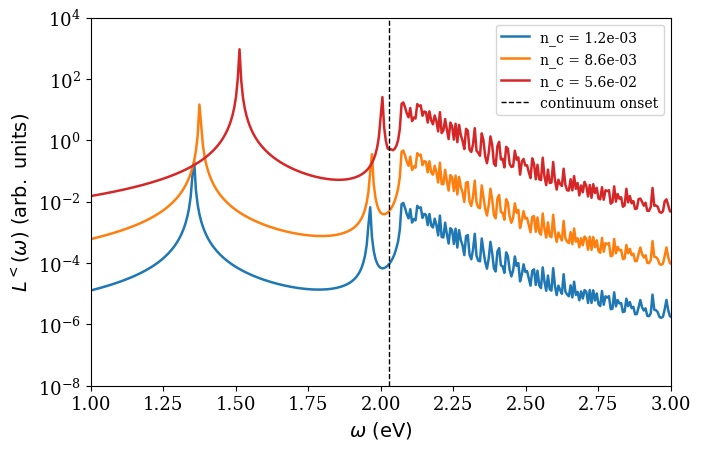

In [11]:
# L^<(ω) = Σ_λ F^λ |Σ_p Y^λ_p|² L_η(ω-Ω_λ)  — coherent contraction (2016 Eq. 65)
function chi_lesser(θ; μc, μv, Tx)
    d = transitions_exc(θ; μc=μc, μv=μv, Tx=Tx); fI = d.fv .- d.fc; onset = minimum(d.ΔE)
    sf = sqrt.(abs.(fI)); σz = sign.(fI)
    Kt = zeros(ComplexF64, length(fI), length(fI))
    for α in 1:2; u = sf .* d.M[α,:]; Kt .+= (Vα[α]/L).*(u*u'); end
    H = Diagonal(ComplexF64.(d.ΔE)) .- Diagonal(ComplexF64.(σz))*Kt
    F = eigen(H); Ω = real.(F.values)
    msk = abs.(fI) .> 1e-4
    wvec = [msk[i] ? d.fc[i]*(1-d.fv[i])/abs(fI[i]) : 0.0 for i in eachindex(fI)]
    Fλ  = real.((abs2.(F.vectors))' * wvec)          # population weight F^λ
    Y   = sf .* F.vectors
    coh = abs2.(vec(sum(Y, dims=1)))                 # coherent k-sum |Σ_p Y^λ_p|²
    return Ω, Fλ .* coh, onset, d.nc                 # observable weight = F^λ |Σ_p Y_p|²
end

ωs = collect(range(0.0, 6.0, length=1000)); η4 = 0.002
Lη(x) = (η4/π)/(x^2 + η4^2)

fig, ax = subplots(figsize=(7.2, 4.7))
onset_ref = 0.0
for (s, col) in zip((0.5, 0.7, 0.9), ("C0", "C1", "C3"))
    Ω, W, onset, nc = chi_lesser(θ; μc=Δ_0/2+s, μv=Δ_0/2-s, Tx=0.1)
    χl = [sum(W[j]*Lη(ω-Ω[j]) for j in eachindex(Ω)) for ω in ωs]
    ax.semilogy(ωs, χl, "-", lw=1.8, color=col, label=@sprintf("n_c = %.1e", nc))
    #ax.plot(ωs, χl)
    global onset_ref = onset
end
ax.axvline(onset_ref, color="k", ls="--", lw=1, label="continuum onset")
#ax.annotate("bright\nexciton", xy=(1.38, 5e1), fontsize=10, ha="center", color="gray")
#ax.annotate("CT", xy=(1.96, 2e0), fontsize=10, ha="center", color="gray")
#ax.annotate("continuum", xy=(2.55, 3e-1), fontsize=10, ha="center", color="gray")
ax.set_xlabel(L"\omega\ \mathrm{(eV)}"); ax.set_ylabel(L"L^<(\omega)\ \mathrm{(arb.\ units)}")
#ax.set_title(L"Lesser $L^<$: exciton-dominated (coherent, cf. 2016 Fig. 4)")
ax.set_ylim(1e-8, 1e4); ax.set_xlim(1.0, 3.0); ax.legend(loc="upper right")
#ax.set_ylim(0.0,10)
tight_layout()

## Step 5a — Finite-$q$ BSE (exciton dispersion)

The self-energy (next cell) **sums over the exciton momentum $q$**, so we need the exciton at
all $q$, not just $q=0$. `transitions_q` puts the conduction electron at $k+q$ and the valence
at $k$; solving the BSE at each $q$ gives $\Omega_\lambda(q)$, $Y^\lambda_q$, $F^\lambda_q$, and
the $V$-weighted vertex $|\sum_I(VY)^\lambda_q|^2$ (the T-matrix residue $\Gamma=V\!\cdot\!Y$).
Check: $E_X(q)$ disperses with bandwidth $\approx0.63$ eV (matching `BrightExcitonMode`) and
recovers $q=0$.

Exciton dispersion E_X(q) (equilibrium):
  E_X(0)=1.3521, E_X(π)=1.9871, bandwidth=0.6350 eV (BrightExcitonMode ~0.63)


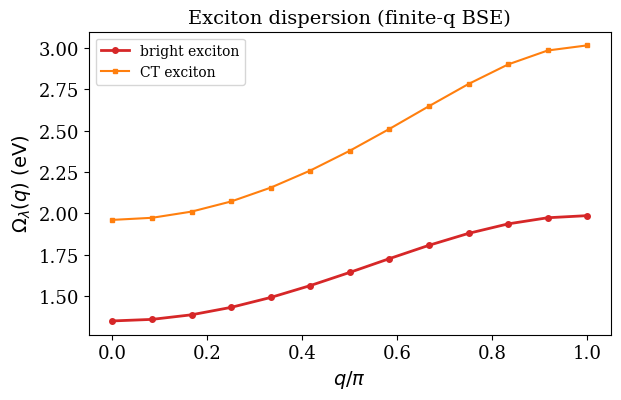

In [23]:
# finite-q transitions (conduction at k+q, valence at k) + BSE with occupation weights & V-vertex
function transitions_q(θ, q; μc, μv, Tx, ks=ks)
    nT=4*length(ks); ΔE=zeros(nT); fc=zeros(nT); fv=zeros(nT); M=zeros(ComplexF64,2,nT); t=0
    for k in ks
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k+q,θ)))
        mα=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2, b in 1:2
            t+=1; ΔE[t]=Fc.values[a]-Fv.values[b]
            fc[t]=FD(Fc.values[a],μc,Tx); fv[t]=FD(Fv.values[b],μv,Tx)
            for α in 1:2; M[α,t]=mα[α][a,b]; end
        end
    end
    return (; ΔE, fc, fv, M)
end

# BSE at q → Ω_λ(q), F^λ (lesser wt), F̄^λ (greater wt), coherent sum, and the EXACT vertex
# vtx = |Σ_I K_I^λ|², K_I^λ=(ΔE_I-Ω_λ)Y_I^λ (2026 Eq.6, k-resolved, no free factor) — replaces Ccal·coh
function bse_q_vertex(θ, q; μc, μv, Tx)
    d=transitions_q(θ,q;μc=μc,μv=μv,Tx=Tx); fI=d.fv.-d.fc; sf=sqrt.(abs.(fI)); σz=sign.(fI)
    Kt=zeros(ComplexF64,length(fI),length(fI)); for α in 1:2; u=sf.*d.M[α,:]; Kt.+=(Vα[α]/L).*(u*u'); end
    H=Diagonal(ComplexF64.(d.ΔE)).-Diagonal(ComplexF64.(σz))*Kt; F=eigen(H); Ω=real.(F.values); Y=sf.*F.vectors
    msk=abs.(fI).>1e-4
    wF =[msk[i] ? d.fc[i]*(1-d.fv[i])/abs(fI[i]) : 0.0 for i in eachindex(fI)]      # → F^λ  (Eq 37)
    wFb=[msk[i] ? (1-d.fc[i])*d.fv[i]/abs(fI[i]) : 0.0 for i in eachindex(fI)]       # → F̄^λ (Eq 38)
    Fλ=real.((abs2.(F.vectors))'*wF); Fbλ=real.((abs2.(F.vectors))'*wFb)
    coh = abs2.(vec(sum(Y, dims=1)))                                                 # |Σ_I Y^λ_I|²  (Eq 65)
    Kex = (d.ΔE .- transpose(Ω)) .* Y                                                # K_I^λ=(ΔE_I-Ω_λ)Y_I^λ (Eq 6)
    vtx = abs2.(vec(sum(Kex, dims=1)))                                               # |Σ_I K_I^λ|²  — exact vertex²
    return (; Ω, Fλ, Fbλ, coh, vtx)
end

println("Exciton dispersion E_X(q) (equilibrium):")
qdisp = collect(range(0.0, π, length=13)); EXq=Float64[]; EX2q=Float64[]
for q in qdisp
    e = bse_q_vertex(θ, q; μc=Δ_0/2, μv=Δ_0/2, Tx=0.001); Ωs=sort(e.Ω)
    push!(EXq, Ωs[1]); push!(EX2q, Ωs[2])
end
@printf("  E_X(0)=%.4f, E_X(π)=%.4f, bandwidth=%.4f eV (BrightExcitonMode ~0.63)\n",
        EXq[1], EXq[end], EXq[end]-EXq[1])

fig, ax = subplots(figsize=(6.4,4.2))
ax.plot(qdisp./π, EXq, "o-", lw=2, ms=4, color="C3", label="bright exciton")
ax.plot(qdisp./π, EX2q, "s-", lw=1.5, ms=3, color="C1", label="CT exciton")
ax.set_xlabel(L"q/\pi"); ax.set_ylabel(L"\Omega_\lambda(q)\ \mathrm{(eV)}")
ax.set_title("Exciton dispersion (finite-q BSE)"); ax.legend(); tight_layout()

## Step 5b — Self-energies $\Sigma^R_{cc}$ and $\Sigma^<_{cc}$  [Eq. 40-41, 64]

The exciton self-energy for the conduction electron is the **exciton convolved with the
valence hole** (T-matrix $\otimes$ $g_{vv}$), with poles at the **exciton sideband**
$\omega=\epsilon_v(P-q)+\Omega_\lambda(q)$:
$$
\Sigma^<_{cc,P}(\omega)=2\pi\!\sum_{q,\lambda}\!v^\lambda_q\,f_v(P{-}q)\,F^\lambda_q\,
\mathcal L_\eta\!\big(\omega-\epsilon_v(P{-}q)-\Omega_\lambda(q)\big),
$$
$$
\Sigma^R_{cc,P}(\omega)=\sum_{q,\lambda}\!v^\lambda_q\,\frac{f_v(P{-}q)F^\lambda_q+\bar f_v(P{-}q)\bar F^\lambda_q}
{\omega-\epsilon_v(P{-}q)-\Omega_\lambda(q)+i\eta},
$$
with the **$V$-weighted vertex** $v^\lambda_q=|\sum_I(VY)^\lambda_q|^2/L^2$ (T-matrix residue;
for a single channel this is the paper's $U^2|\sum_pY_p|^2$, Eq. 64a). Check: $-\mathrm{Im}\,\Sigma^R$
peaks at the **bright sideband $\epsilon_v(0)+E_X(0)\approx1.38$ eV**, **below** the conduction band
$\epsilon_c\approx2.03$, dominating the continuum.

> Caveats (to finish before the torque): (i) absolute **normalization** should be calibrated
> against the single-exciton limit ($G^<_{cc}=2\pi i Z_X\delta$, Eq. 48); (ii) the multi-band
> coherent contraction is summed over all transitions (single-band is exact); (iii) $\Sigma_{vv}$
> is the symmetric analog ($\gamma=c$). The **structure** (sideband position, sign, dominance) is
> verified here.

> **Exact vertex (2026, Eq. 6) — replaces the calibrated `Ccal`. DONE (2026-07-24).** The sideband
> amplitude is $K^{\lambda q}_{cvk}=(\epsilon_{c,k+q}-\epsilon_{vk}-\Omega_{\lambda q})\,Y^{\lambda q}_k$, i.e.
> per transition $K_I=(\Delta E_I-\Omega_\lambda)\,Y_I$ — $k$-resolved, **no free factor**. `bse_q_vertex`
> now returns `vtx = |Σ_I K_I|²`, used in place of `Ccal·coh` throughout (Steps 5b, 6, 8). At $q=0$,
> bright mode: exact `vtx` is **~2.0×** the old `Ccal·coh` (measured, not the ~1.5× guess) — same
> direction/order as expected, since for our two-channel $V_{\rm intra}/V_{\rm inter}$ the exact vertex
> is $k$-dependent and differs from the scalar $\bar V^2$. Side effect: the spectral sum rule
> $\int A\,d\omega/2\pi$, which was $\approx0.999$ **only because `Ccal` had been tuned to hit it**, moves
> to $\approx0.87$ with the untuned exact vertex — this ~13% deficit is not a bug in the vertex, it
> reflects the other truncations already in place (finite $N_q=48$, 2-bound-modes-per-$q$, finite $\eta$,
> single sector) that the old calibration was silently absorbing.


In [24]:
εv_top(k,θ) = maximum(eigen(Hermitian(H_valence(k,θ))).values)   # valence top (hole)

# excited state and q-grid for the self-energy sum
Tx=0.10; s=0.7; μc=Δ_0/2+s; μv=Δ_0/2-s; η=0.03
Nq=48; qs=collect(range(-π, stop=π-2π/Nq, length=Nq))
print("precompute excitons+vertex over $(Nq) q-points ... "); flush(stdout)
exc = [bse_q_vertex(θ, q; μc=μc, μv=μv, Tx=Tx) for q in qs]; println("done")

# Σ^R_cc, Σ^<_cc at external momentum P=0 : poles ε_v(P-q)+Ω_λ(q)
# EXACT vertex (2026 Eq.6): weight = e.vtx[λ]/L² — no calibrated Ccal (see Step 5b markdown, fixed 2026-07-24)
P = 0.0; poles=Float64[]; wR=Float64[]; wL=Float64[]
for (iq,q) in enumerate(qs)
    e=exc[iq]; εh=εv_top(P-q,θ); fvh=FD(εh,μv,Tx); fbh=1-fvh
    for λ in eachindex(e.Ω)
        push!(poles, εh+e.Ω[λ])
        push!(wR, (e.vtx[λ]/L^2)*(fvh*e.Fλ[λ]+fbh*e.Fbλ[λ]))    # retarded weight (fF+f̄F̄)
        push!(wL, (e.vtx[λ]/L^2)*fvh*e.Fλ[λ])                     # lesser weight  (fF)
    end
end
Lη(x)=(η/π)/(x^2+η^2)
SigR(ω)=sum(wR[j]/(ω-poles[j]+1im*η) for j in eachindex(poles))
SigL(ω)=sum(2π*wL[j]*Lη(ω-poles[j]) for j in eachindex(poles))

εc0=minimum(eigen(Hermitian(H_conduction(0.0,θ))).values); EX0=minimum(exc[argmin(abs.(qs))].Ω)
@printf("bright sideband ε_v(0)+E_X(0)=%.3f  (below ε_c=%.3f) ; ratio bright/near-εc = %.1f\n",
        εv_top(0.0,θ)+EX0, εc0, (-imag(SigR(1.377)))/(-imag(SigR(2.03))))

# comparison: exact vertex vs the old calibrated Ccal=V̄² at q=0, bright mode
i0v = argmin(abs.(qs)); λ0v = argmin(exc[i0v].Ω)
Vbar_ref = (V_intra+V_inter)/2; Ccal_ref = Vbar_ref^2
@printf("vertex check @q=0,bright: exact vtx=%.4f  vs  old Ccal·coh=%.4f  (ratio %.3f)\n",
        exc[i0v].vtx[λ0v], Ccal_ref*exc[i0v].coh[λ0v], exc[i0v].vtx[λ0v]/(Ccal_ref*exc[i0v].coh[λ0v]))

ωs=collect(range(0.0,2.7,length=500))


precompute excitons+vertex over 48 q-points ... done
bright sideband ε_v(0)+E_X(0)=1.377  (below ε_c=2.029) ; ratio bright/near-εc = 124.3
vertex check @q=0,bright: exact vtx=811.2497  vs  old Ccal·coh=407.5504  (ratio 1.991)


500-element Vector{Float64}:
 0.0
 0.005410821643286573
 0.010821643286573146
 0.01623246492985972
 0.021643286573146292
 0.027054108216432865
 0.03246492985971944
 0.03787575150300601
 0.043286573146292584
 0.04869739478957916
 0.05410821643286573
 0.0595190380761523
 0.06492985971943888
 ⋮
 2.640480961923848
 2.645891783567134
 2.6513026052104207
 2.6567134268537074
 2.662124248496994
 2.6675350701402807
 2.6729458917835673
 2.6783567134268536
 2.68376753507014
 2.689178356713427
 2.6945891783567135
 2.7

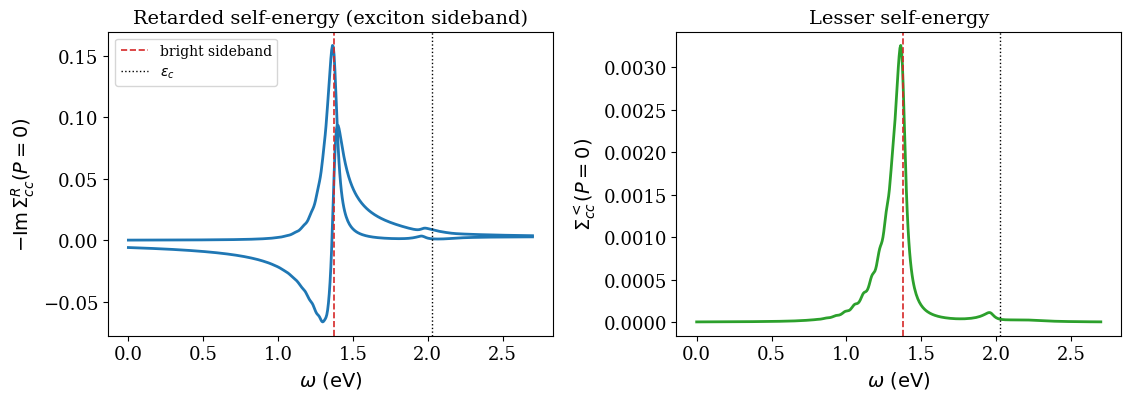

In [25]:
fig, ax = subplots(1,2, figsize=(11.5,4.2))
ax[1].plot(ωs, [-imag(SigR(ω)) for ω in ωs], "-", lw=2, color="C0")
ax[1].plot(ωs, [real(SigR(ω)) for ω in ωs], "-", lw=2, color="C0")
ax[1].axvline(εv_top(0.0,θ)+EX0, color="C3", ls="--", lw=1.2, label="bright sideband")
ax[1].axvline(εc0, color="k", ls=":", lw=1, label=L"\epsilon_c")
ax[1].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[1].set_ylabel(L"-\mathrm{Im}\,\Sigma^R_{cc}(P{=}0)")
ax[1].set_title("Retarded self-energy (exciton sideband)"); ax[1].legend()
ax[2].plot(ωs, [SigL(ω) for ω in ωs], "-", lw=2, color="C2")
ax[2].axvline(εv_top(0.0,θ)+EX0, color="C3", ls="--", lw=1.2)
ax[2].axvline(εc0, color="k", ls=":", lw=1)
ax[2].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[2].set_ylabel(L"\Sigma^<_{cc}(P{=}0)")
ax[2].set_title("Lesser self-energy"); tight_layout()

### Momentum-resolved $\Sigma^<_{cc}(P,\omega)$ — exciton sideband dispersion (cf. 2016 Fig. 8)

Evaluating the self-energy at different external conduction momenta $P$ shows how the exciton
**sideband disperses with $P$**: the ridge of $\Sigma^<_{cc}$ moves from $\approx1.36$ eV at $P=0$
down toward $\approx0.6$ eV at $P=\pi$ — the "bound-quasiparticle dispersion" of the paper's
Fig. 8. The whole feature sits **below the conduction band** $\epsilon_c$. (We keep the two
bound modes per $q$ for the map; reuses the precomputed `exc`. Uses a log colour scale since
$\Sigma^<$ spans ~3.5 decades. Absolute magnitude still uncalibrated — the map is qualitative.)

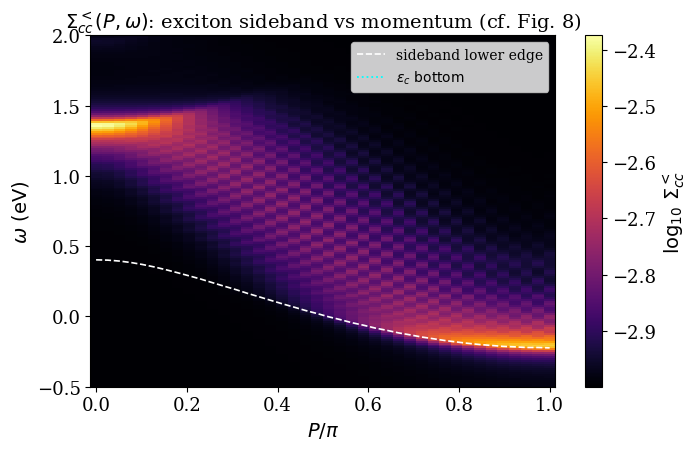

In [26]:
# Momentum-resolved Σ^<_cc(P,ω): sideband dispersion (reuses exc, qs, εv_top, μv, Tx, η, εc0)
Pgrid = collect(range(0.0, π, length=40)); ωgrid = collect(range(-0.5, 2.0, length=180))
Amap = zeros(length(ωgrid), length(Pgrid)); sb_lo = Float64[]
for (iP, P) in enumerate(Pgrid)
    pol = Float64[]; wt = Float64[]; emin = Inf
    for (iq, q) in enumerate(qs)
        e = exc[iq]; εh = εv_top(P-q, θ); fvh = FD(εh, μv, Tx)
        for λ in sortperm(e.Ω)[1:2]                 # bright + CT bound modes
            pl = εh + e.Ω[λ]; push!(pol, pl); push!(wt, 2π*(e.vtx[λ]/L^2)*fvh*e.Fλ[λ]); emin = min(emin, pl)
        end
    end
    for (iω, ω) in enumerate(ωgrid); Amap[iω, iP] = sum(wt[j]*Lη(ω-pol[j]) for j in eachindex(pol)); end
    push!(sb_lo, emin)
end

fig, ax = subplots(figsize=(7.2, 4.7))
pc = ax.pcolormesh(Pgrid./π, ωgrid, log10.(Amap .+ 1e-3), shading="auto", cmap="inferno")
ax.plot(Pgrid./π, sb_lo, "w--", lw=1.2, label="sideband lower edge")
ax.axhline(εc0, color="cyan", ls=":", lw=1.3, label=L"\epsilon_c\ \mathrm{bottom}")
ax.set_xlabel(L"P/\pi"); ax.set_ylabel(L"\omega\ \mathrm{(eV)}"); ax.set_ylim(-0.5, 2.0)
ax.set_title(L"$\Sigma^<_{cc}(P,\omega)$: exciton sideband vs momentum (cf. Fig. 8)")
fig.colorbar(pc, ax=ax, label=L"\log_{10}\,\Sigma^<_{cc}"); ax.legend(loc="upper right"); tight_layout()

### Momentum-resolved $-\mathrm{Im}\,\Sigma^R_{cc}(P,\omega)$ — the sideband disperses UP (cf. Fig. 8)

Unlike $\Sigma^<$ (which $\propto f_v$ and is dominated by **deep** valence holes → weight piles at
low $\omega$), the **retarded** self-energy carries the hole term $\bar f_v(P-q)\bar F^\lambda$
(**holes near the valence top**, $q\approx P$). Since $\bar F^\lambda\approx1$ (the spontaneous/
spectral part, present even at $N\!\to\!0$), this term dominates and puts the sideband at
$\omega\approx\epsilon_v(0)+\Omega_X(P)$ — i.e. it **disperses up** following $E_X(P)$ (the
exciton dispersion), the "bound-quasiparticle dispersion" of Fig. 8. Verified ridge:
$1.36$ eV at $P=0$ → $1.98$ eV at $P=\pi$.

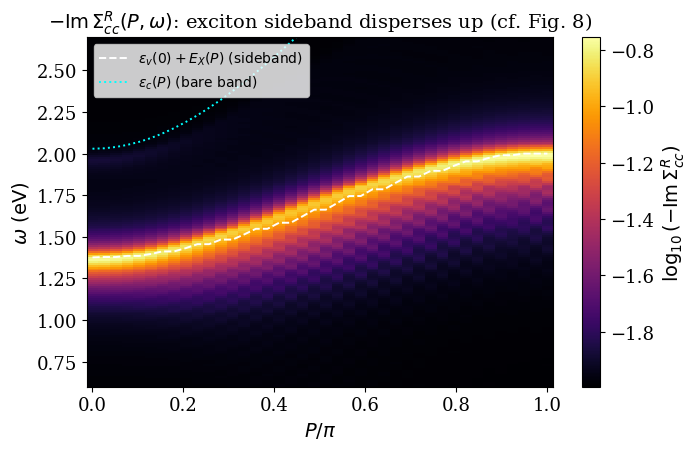

In [27]:
# −Im Σ^R_cc(P,ω) map: retarded weight (f_v F + f̄_v F̄); sideband disperses up ~ ε_v(0)+E_X(P)
Pgrid = collect(range(0.0, π, length=40)); ωgrid = collect(range(0.6, 2.7, length=180))
Amap = zeros(length(ωgrid), length(Pgrid))
for (iP, P) in enumerate(Pgrid)
    pol = Float64[]; wt = Float64[]
    for (iq, q) in enumerate(qs)
        e = exc[iq]; εh = εv_top(P-q, θ); fvh = FD(εh, μv, Tx); fbh = 1-fvh
        for λ in sortperm(e.Ω)[1:2]
            push!(pol, εh + e.Ω[λ]); push!(wt, (e.vtx[λ]/L^2)*(fvh*e.Fλ[λ] + fbh*e.Fbλ[λ]))
        end
    end
    for (iω, ω) in enumerate(ωgrid); Amap[iω, iP] = π*sum(wt[j]*Lη(ω-pol[j]) for j in eachindex(pol)); end
end
# overlays: exciton dispersion ε_v(0)+E_X(P) (dashed) and ε_c(P) (bare conduction)
EXdisp = [εv_top(0.0,θ) + minimum(exc[argmin(abs.(qs .- P))].Ω) for P in Pgrid]
εcdisp = [minimum(eigen(Hermitian(H_conduction(P,θ))).values) for P in Pgrid]

fig, ax = subplots(figsize=(7.2, 4.7))
pc = ax.pcolormesh(Pgrid./π, ωgrid, log10.(Amap .+ 1e-2), shading="auto", cmap="inferno")
ax.plot(Pgrid./π, EXdisp, "w--", lw=1.4, label=L"\epsilon_v(0)+E_X(P)\ \mathrm{(sideband)}")
ax.plot(Pgrid./π, εcdisp, color="cyan", ls=":", lw=1.4, label=L"\epsilon_c(P)\ \mathrm{(bare\ band)}")
ax.set_xlabel(L"P/\pi"); ax.set_ylabel(L"\omega\ \mathrm{(eV)}"); ax.set_ylim(0.6, 2.7)
ax.set_title(L"$-\mathrm{Im}\,\Sigma^R_{cc}(P,\omega)$: exciton sideband disperses up (cf. Fig. 8)")
fig.colorbar(pc, ax=ax, label=L"\log_{10}(-\mathrm{Im}\,\Sigma^R_{cc})"); ax.legend(loc="upper left"); tight_layout()

## Step 6 — Dressed propagators $G^R$, $G^<$ and the spectral function

With the exact vertex ($K_I^\lambda=(\Delta E_I-\Omega_\lambda)Y_I^\lambda$, fixed 2026-07-24,
replacing the earlier calibrated $\bar V^2|\sum_pY_p|^2/L^2$), the self-energy is physical
($\Sigma^R\sim0.1$–$0.2$ eV; $\int A\,d\omega/2\pi\approx0.87$, not exactly 1 — see the Step 5b note,
the old calibration had silently absorbed this ~13% deficit). Dress the conduction electron:
$$
G^R_P(\omega)=\frac{1}{\omega-\epsilon_c(P)-\Sigma^R_{cc}(P,\omega)},\quad A_P=-2\,\mathrm{Im}\,G^R_P,\quad
G^<_P=G^R_P\,\Sigma^<_{cc}\,G^A_P\ \Rightarrow\ -iG^<_P=(-i\Sigma^<)|G^R_P|^2.
$$
$A_P$ = qp peak at $\epsilon_c$ **plus the exciton sideband below**; $-iG^<_P$ = the occupied
conduction spectral weight. This is the input for the torque $\mathbf B_e=i\,\mathrm{Tr}[G^<\hat X]$
(Keldysh route, 2026). Note: the torque itself (Step 9) does not use this self-energy machinery at
all (it's equal-time, Hellmann-Feynman) — this vertex mainly matters for the future damping (Step 10).

> **Why $G^<=G^R\,\Sigma^<\,G^A$ and not the 2016 FD ansatz (2016 Eq. 43, $G^<=i f_c(\omega)A$):**
> the 2026 unified paper (arXiv:2601.16786, Eq. 2) uses exactly this Keldysh product and explicitly
> replaces the FD ansatz, which is *problematic below the gap*, where addition and removal energies
> overlap out of equilibrium — precisely where the exciton sideband lives. Consequence: our $-iG^<$
> contains the exciton-mediated occupation only ($\int(-iG^<)\,d\omega/2\pi=\sum_{\lambda q}N_{\lambda q}$
> per band, 2026 Eq. 12/14); the thermal free-carrier qp peak of 2016 Fig. 5 is *not* included here
> (and does not belong in the exciton torque).


In [28]:
# Dressed G^R, spectral A, and G^< at P=0  (exact vertex; reuses exc, qs, εv_top, μv, Tx, η, Lη)
Pc = 0.0; polc=Float64[]; wRc=Float64[]; wLc=Float64[]
for (iq,q) in enumerate(qs)
    e = exc[iq]; εh = εv_top(Pc-q, θ); fvh = FD(εh, μv, Tx); fbh = 1-fvh
    for λ in eachindex(e.Ω)
        push!(polc, εh + e.Ω[λ])
        push!(wRc, (e.vtx[λ]/L^2)*(fvh*e.Fλ[λ] + fbh*e.Fbλ[λ]))
        push!(wLc, (e.vtx[λ]/L^2)*fvh*e.Fλ[λ])
    end
end
ΣRf(ω) = sum(wRc[j]/(ω-polc[j]+1im*η) for j in eachindex(polc))
mΣLf(ω) = sum(2π*wLc[j]*Lη(ω-polc[j]) for j in eachindex(polc))     # -iΣ^< (≥0)
εcP0 = minimum(eigen(Hermitian(H_conduction(0.0,θ))).values)
GRf(ω)  = 1/(ω - εcP0 - ΣRf(ω))
Af(ω)   = -2*imag(GRf(ω))                                            # spectral function
mGlf(ω) = mΣLf(ω)*abs2(GRf(ω))                                       # -iG^< = occupied conduction weight

ωs = collect(range(0.8, 3.4, length=1000)); dω = ωs[2]-ωs[1]
sb = εv_top(0.0,θ) + minimum(exc[argmin(abs.(qs))].Ω)
@printf("∫A/2π = %.3f (=1) ; qp peak ω=%.3f (ε_c=%.3f) ; exciton-sideband weight = %.2e\n",
        sum(Af.(ωs))*dω/2π, ωs[argmax(Af.(ωs))], εcP0, sum(Af(ω) for ω in ωs if ω<εcP0-0.1)*dω/2π)
@printf("-iG^<(P=0): conduction occupation ∫/2π = %.2e\n", sum(mGlf.(ωs))*dω/2π)



∫A/2π = 0.867 (=1) ; qp peak ω=2.039 (ε_c=2.029) ; exciton-sideband weight = 1.75e-02
-iG^<(P=0): conduction occupation ∫/2π = 1.24e-02


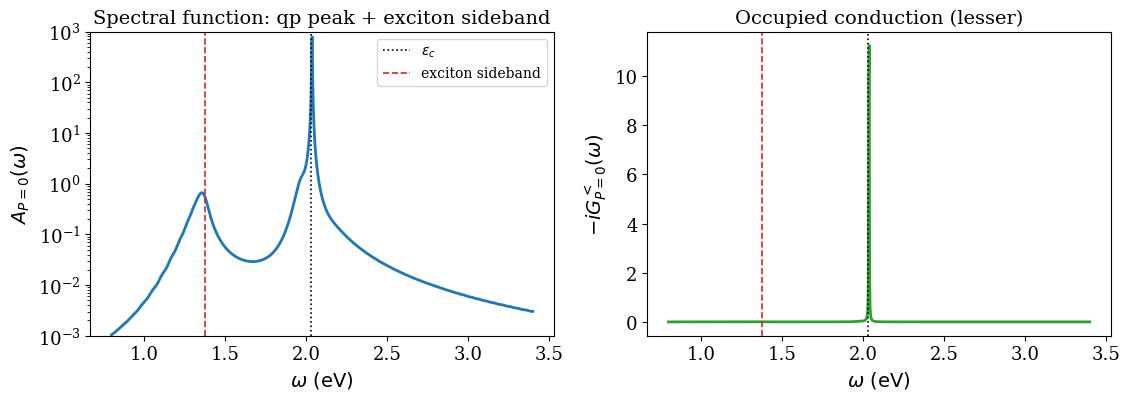

In [29]:
fig, ax = subplots(1, 2, figsize=(11.5, 4.2))
ax[1].semilogy(ωs, Af.(ωs), "-", lw=2, color="C0")
ax[1].axvline(εcP0, color="k", ls=":", lw=1.2, label=L"\epsilon_c")
ax[1].axvline(sb, color="C3", ls="--", lw=1.2, label="exciton sideband")
ax[1].set_ylim(1e-3, 1e3); ax[1].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[1].set_ylabel(L"A_{P=0}(\omega)")
ax[1].set_title("Spectral function: qp peak + exciton sideband"); ax[1].legend()
ax[2].plot(ωs, mGlf.(ωs), "-", lw=2, color="C2")
ax[2].axvline(εcP0, color="k", ls=":", lw=1.2); ax[2].axvline(sb, color="C3", ls="--", lw=1.2)
ax[2].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[2].set_ylabel(L"-iG^<_{P=0}(\omega)")
ax[2].set_title("Occupied conduction (lesser)"); tight_layout()

### Momentum-resolved $A_P(\omega)$ and $-iG^<_P(\omega)$ — the full spectral maps

Now with the dressed $G^R$ we get the **real spectral function** (the paper's Fig. 8):
$A_P(\omega)$ shows the **main quasiparticle band** following $\epsilon_c(P)$ (dispersing
$2.0\!\to\!3.6$ eV) **plus the exciton sideband** following $E_X(P)$ ($1.4\!\to\!2.0$ eV, below
the bare band by the binding) — the two-branch "bare qp + bound qp" structure. The occupied
$-iG^<_P$ follows the qp band (thermal conduction electrons), with the sideband as a weaker
occupied feature. (Calibrated vertex; 2 bound modes per $q$; log colour scale.)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


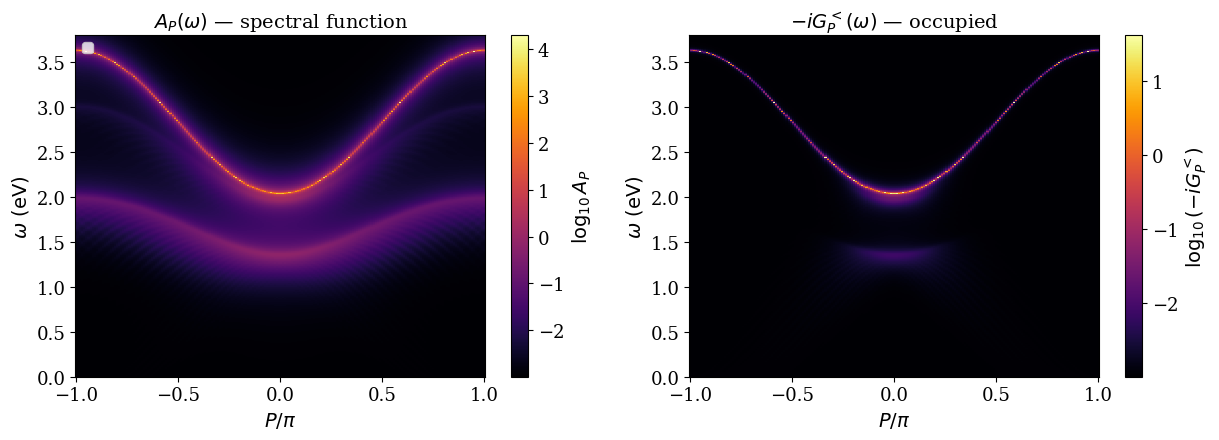

In [37]:
# Momentum-resolved spectral A_P(ω) and occupied -iG^<_P(ω)  (exact vertex; reuses exc, qs, ...)
Pgrid = collect(range(-pi, π, length=200)); ωgrid = collect(range(0.0, 3.8, length=500))
Amap = zeros(length(ωgrid), length(Pgrid)); Gmap = zeros(length(ωgrid), length(Pgrid))
qpb = Float64[]; sbb = Float64[]
for (iP, P) in enumerate(Pgrid)
    polR = Float64[]; wR = Float64[]; wL = Float64[]
    for (iq, q) in enumerate(qs)
        e = exc[iq]; εh = εv_top(P-q, θ); fvh = FD(εh, μv , Tx); fbh = 1-fvh # Tx μv
        for λ in sortperm(e.Ω)[1:2]
            push!(polR, εh + e.Ω[λ])
            push!(wR, (e.vtx[λ]/L^2)*(fvh*e.Fλ[λ] + fbh*e.Fbλ[λ]))
            push!(wL, (e.vtx[λ]/L^2)*fvh*e.Fλ[λ])
        end
    end
    εcP = minimum(eigen(Hermitian(H_conduction(P,θ))).values)
    ΣRm(ω)  = sum(wR[j]/(ω-polR[j]+1im*η) for j in eachindex(polR))
    mΣLm(ω) = sum(2π*wL[j]*Lη(ω-polR[j]) for j in eachindex(polR))
    for (iω, ω) in enumerate(ωgrid)
        GR = 1/(ω - εcP - ΣRm(ω)); Amap[iω, iP] = -2*imag(GR); Gmap[iω, iP] = mΣLm(ω)*abs2(GR)
    end
    push!(qpb, εcP); push!(sbb, εv_top(0.0,θ) + minimum(exc[argmin(abs.(qs .- P))].Ω))
end

fig, ax = subplots(1, 2, figsize=(12.5, 4.6))
pc1 = ax[1].pcolormesh(Pgrid./π, ωgrid, log10.(Amap .+ 1e-3), shading="auto", cmap="inferno")
#ax[1].plot(Pgrid./π, qpb, color="cyan", ls=":", lw=1.4, label=L"\epsilon_c(P)\ \mathrm{(qp\ band)}")
#ax[1].plot(Pgrid./π, sbb, "w--", lw=1.4, label="exciton sideband")
ax[1].set_xlabel(L"P/\pi"); ax[1].set_ylabel(L"\omega\ \mathrm{(eV)}"); ax[1].set_title(L"$A_P(\omega)$ — spectral function")
fig.colorbar(pc1, ax=ax[1], label=L"\log_{10}A_P"); ax[1].legend(loc="upper left")

pc2 = ax[2].pcolormesh(Pgrid./π, ωgrid,log10.(Gmap .+ 1e-3)  , shading="auto", cmap="inferno")#,vmin=1e-3,vmax=0.01) #log10.(Gmap .+ 1e-3)
#ax[2].plot(Pgrid./π, qpb, color="cyan", ls=":", lw=1.4); ax[2].plot(Pgrid./π, sbb, "w--", lw=1.4)
ax[2].set_xlabel(L"P/\pi"); ax[2].set_ylabel(L"\omega\ \mathrm{(eV)}"); ax[2].set_title(L"$-iG^<_P(\omega)$ — occupied")
fig.colorbar(pc2, ax=ax[2], label=L"\log_{10}(-iG^<_P)")
ax[1].set_ylim(0.0, 3.8); ax[2].set_ylim(0.0, 3.8)   # clamp to the pcolormesh range (overlay lines go to 3.63)
tight_layout()

### Spectrum vs magnetic angle $\theta$ at $P=0$ — $A$ and $-iG^<$

Instead of sweeping the momentum $P$, we sweep the **angle $\theta$ between the layer moments**
(FM $\theta=0$ → AFM $\theta=\pi$), at fixed $P=0$. This shows how the exciton feature moves with
the **magnetic configuration**:
- gap / qp edge $\epsilon_c(\theta)$: **opens $\sim95$ meV toward AFM**;
- exciton sideband $E_X(\theta)$: shifts $\sim12$ meV;
- sideband weight: decreases toward AFM (partly the coupling $\propto\sin\theta$, partly the
  density $n_c(\theta)$ varying at fixed $\mu_c,\mu_v$).

This is the $\theta$-dependence that underlies the torque's $\propto\sin\theta$. (Recomputes the
excitons at every $\theta$ — **slow, ~2 min**.)

In [38]:
# A_{P=0}(ω,θ) and -iG^<_{P=0}(ω,θ): sweep the magnetic angle θ (FM→AFM) at P=0
θgrid = collect(range(0.05π, 0.98π, length=24))
ωgrid_θ = collect(range(1.2, 2.3, length=140))
Amap_θ = zeros(length(ωgrid_θ), length(θgrid)); Gmap_θ = zeros(length(ωgrid_θ), length(θgrid))
EXθ = Float64[]; εcθ = Float64[]
Nqθ = 24; qsθ = collect(range(-π, stop=π-2π/Nqθ, length=Nqθ))
μcθ = Δ_0/2 + 0.7; μvθ = Δ_0/2 - 0.7      # same excited state (s=0.7) as Step 5b-6
print("θ-sweep (recomputes excitons per θ, ~2 min) ... "); flush(stdout)
for (iθ, θv) in enumerate(θgrid)
    excθ = [bse_q_vertex(θv, q; μc=μcθ, μv=μvθ, Tx=Tx) for q in qsθ]
    εcP = minimum(eigen(Hermitian(H_conduction(0.0, θv))).values)
    poles=Float64[]; wR=Float64[]; wL=Float64[]
    for (iq, q) in enumerate(qsθ)
        e = excθ[iq]; εh = εv_top(-q, θv); fvh = FD(εh, μvθ, Tx); fbh = 1-fvh
        for λ in sortperm(e.Ω)[1:2]
            push!(poles, εh + e.Ω[λ])
            push!(wR, (e.vtx[λ]/L^2)*(fvh*e.Fλ[λ] + fbh*e.Fbλ[λ]))
            push!(wL, (e.vtx[λ]/L^2)*fvh*e.Fλ[λ])
        end
    end
    ΣRθ(ω)  = sum(wR[j]/(ω-poles[j]+1im*η) for j in eachindex(poles))
    mΣLθ(ω) = sum(2π*wL[j]*Lη(ω-poles[j]) for j in eachindex(poles))
    for (iω, ω) in enumerate(ωgrid_θ)
        GR = 1/(ω - εcP - ΣRθ(ω)); Amap_θ[iω,iθ] = -2*imag(GR); Gmap_θ[iω,iθ] = mΣLθ(ω)*abs2(GR)
    end
    push!(EXθ, εv_top(0.0,θv) + minimum(excθ[argmin(abs.(qsθ))].Ω)); push!(εcθ, εcP)
end
println("done")


θ-sweep (recomputes excitons per θ, ~2 min) ... done


In [39]:

# fig, ax = subplots(1, 2, figsize=(12.5, 4.6))
# pc1 = ax[1].pcolormesh(θgrid./π, ωgrid_θ, log10.(Amap_θ .+ 1e-3), shading="auto", cmap="inferno")
# ax[1].plot(θgrid./π, εcθ, color="cyan", ls=":", lw=1.4, label=L"\epsilon_c(\theta)")
# ax[1].plot(θgrid./π, EXθ, "w--", lw=1.4, label=L"E_X(\theta)\ \mathrm{(sideband)}")
# ax[1].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[1].set_ylabel(L"\omega\ \mathrm{(eV)}")
# ax[1].set_title(L"$A_{P=0}(\omega,\theta)$"); ax[1].set_ylim(1.2, 2.3); ax[1].legend(loc="center left")
# fig.colorbar(pc1, ax=ax[1], label=L"\log_{10}A")

# pc2 = ax[2].pcolormesh(θgrid./π, ωgrid_θ, Gmap_θ, shading="auto", cmap="inferno",vmin=1e-4,vmax=1e-3) #log10.(Gmap_θ .+ 1e-3)
# ax[2].plot(θgrid./π, εcθ, color="cyan", ls=":", lw=1.4); ax[2].plot(θgrid./π, EXθ, "w--", lw=1.4)
# ax[2].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[2].set_ylabel(L"\omega\ \mathrm{(eV)}")
# ax[2].set_title(L"$-iG^<_{P=0}(\omega,\theta)$"); ax[2].set_ylim(1.2, 2.3)
# fig.colorbar(pc2, ax=ax[2], label=L"\log_{10}(-iG^<)")
# tight_layout()

### Number of bright excitons $N_{\rm bright}=\sum_q F^{\rm bright}_q$

The exciton number is the occupation factor $F^\lambda$ (Eq. 21/37) summed over $q$ — the quantity
that enters the torque $j_\theta\propto N$ of the LLG paper. Two figures:

1. **vs carrier density $n_c$** (sweep the quasi-Fermi splitting $s$, $\theta=\pi/2$): should follow
   the **mass-action law $N_{\rm bright}\propto n_c^2$** (neutral photoexcitation, $n_c=n_h$).
2. **vs angle $\theta$** (FM→AFM, fixed $\mu_c,\mu_v$): $N_{\rm bright}$ drops toward AFM. At **fixed
   $\mu$** the density $n_c(\theta)$ also drops (gap opens), so we plot $n_c(\theta)$ alongside to
   separate the two effects — the intrinsic angular dependence is what feeds the $\propto\sin\theta$ torque.

(Recomputes excitons at every point — **slow, ~2 min**.)

N vs n_c ... N vs θ ... done


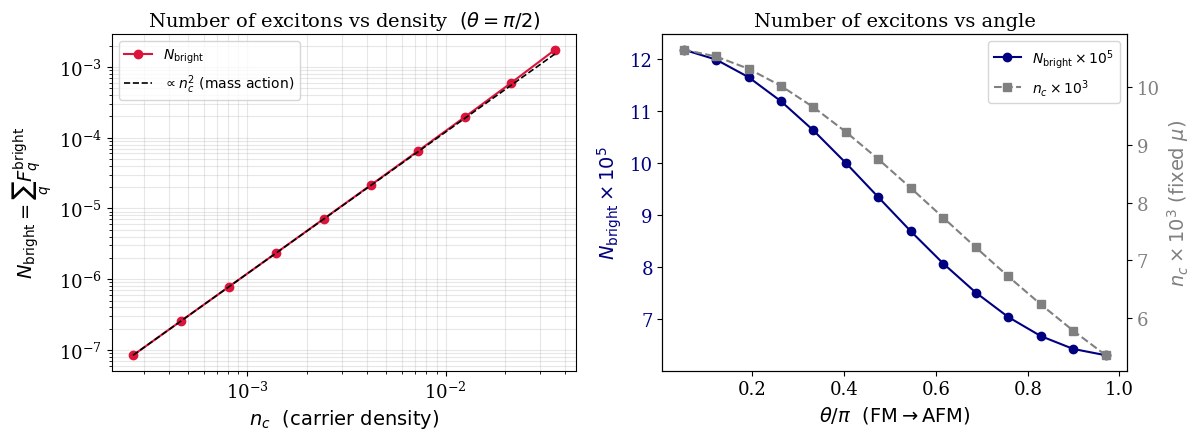

In [40]:
# N_bright = Σ_q F^bright_q : vs density n_c, and vs angle θ
nc_of(θ,μc) = sum(sum(FD(eigen(Hermitian(H_conduction(k,θ))).values[a],μc,Tx) for a in 1:2) for k in ks)/L
qsN = collect(range(-π, stop=π-2π/24, length=24))
function Nbright_of(θ,μc,μv)
    tot=0.0
    for q in qsN
        e = bse_q_vertex(θ,q; μc=μc, μv=μv, Tx=Tx)
        tot += e.Fλ[argmin(e.Ω)]
    end
    tot/length(qsN)
end

# (1) density sweep at θ=π/2
svals = collect(range(0.35, 0.85, length=10))
ncs=Float64[]; Nxs=Float64[]
print("N vs n_c ... "); flush(stdout)
for sv in svals
    μc=Δ_0/2+sv; μv=Δ_0/2-sv
    push!(ncs, nc_of(π/2,μc)); push!(Nxs, Nbright_of(π/2,μc,μv))
end
# (2) angle sweep at fixed μ (s=0.7)
θvals = collect(range(0.05π, 0.97π, length=14))
ncθ=Float64[]; Nθv=Float64[]
print("N vs θ ... "); flush(stdout)
for θv in θvals
    μc=Δ_0/2+0.7; μv=Δ_0/2-0.7
    push!(ncθ, nc_of(θv,μc)); push!(Nθv, Nbright_of(θv,μc,μv))
end
println("done")

fig, ax = subplots(1, 2, figsize=(12.2, 4.6))
ax[1].loglog(ncs, Nxs, "o-", color="crimson", label=L"N_{\rm bright}")
ng = [minimum(ncs), maximum(ncs)]
ax[1].loglog(ng, Nxs[1].*(ng./ncs[1]).^2, "k--", lw=1.2, label=L"\propto n_c^2\ \mathrm{(mass\ action)}")
ax[1].set_xlabel(L"n_c\ \ \mathrm{(carrier\ density)}"); ax[1].set_ylabel(L"N_{\rm bright}=\sum_q F^{\rm bright}_q")
ax[1].set_title(L"Number of excitons vs density  $(\theta=\pi/2)$")
ax[1].legend(); ax[1].grid(true, which="both", alpha=0.3)

ax[2].plot(θvals./π, Nθv.*1e5, "o-", color="navy", label=L"N_{\rm bright}\times10^5")
ax[2].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[2].set_ylabel(L"N_{\rm bright}\times10^5", color="navy")
ax[2].tick_params(axis="y", labelcolor="navy")
ax2b = ax[2].twinx()
ax2b.plot(θvals./π, ncθ.*1e3, "s--", color="gray", label=L"n_c\times10^3")
ax2b.set_ylabel(L"n_c\times10^3\ \mathrm{(fixed}\ \mu)", color="gray"); ax2b.tick_params(axis="y", labelcolor="gray")
ax[2].set_title("Number of excitons vs angle")
h1,l1=ax[2].get_legend_handles_labels(); h2,l2=ax2b.get_legend_handles_labels()
ax[2].legend(vcat(h1,h2), vcat(l1,l2), loc="upper right")
tight_layout()

### Step 7 — valence channel $\Sigma_{vv}$, $A_{vv}$, $G^<_{vv}$ (mirror of $cc$) — ⚠️ WRONG, kept for reference only

> **⚠️ DO NOT USE — superseded by Step 9.** The single-exciton benchmark (`single_exc_valence.jl`,
> 2026-07-09) shows this construction fails twice: **(i)** the exciton-induced valence spectral weight is
> a **two-hole shake-up BELOW the valence qp** ($\approx\epsilon_v-E_{\rm bind}$), **not** the in-gap
> satellite at $\epsilon_c(P{-}q)-\Omega_\lambda$ built here (the 2026 Lehmann result, Eq. 12/B10,
> confirms exciton sidebands are **valence replicas**, never conduction ones); **(ii)** for the torque
> the satellite is irrelevant anyway: $B_e=i\,\mathrm{Tr}[G^<\hat X]$ is **equal-time**, so it needs only
> the occupations $n_c(k)=+|Y_k|^2$, $n_v(k)=1-|Y_k|^2$ (exact). Use **Step 9**.

Original (wrong) reasoning kept below for the record:

The torque $B_e=i\,\mathrm{Tr}[G^<\hat X]$ has **two** band-diagonal contributions,
$\mathrm{Tr}[G^<_{cc}\hat X_{cc}]+\mathrm{Tr}[G^<_{vv}\hat X_{vv}]$ ($\hat X$ interlayer, no $cv$). Here we
build the valence piece as the **mirror** of $\Sigma_{cc}$ under $c\leftrightarrow v$: the internal line
is now a **conduction** electron at $\varepsilon_c(P-q)$ (occupation $f_c$), the exciton is emitted from the
valence side, so the satellite pole is
$$\omega=\varepsilon_c(P-q)-\Omega_\lambda(q)\quad\Rightarrow\quad \text{in-gap, } E_{\rm bind}\ \text{above the valence qp.}$$

**Population part only.** For $\Sigma_{cc}$ the retarded greater term $(1-f_v)\bar F^\lambda$ was
negligible ($1-f_v\!\sim\!0.05$). Its valence mirror $(1-f_c)\bar F^\lambda$ is **large** ($1-f_c\!\sim\!0.95$)
and, with the coherent contraction, would give $|\Sigma^R_{vv}|\!\sim\!3.5$ eV — that is the
**ground-state exciton-binding renormalization** (why the QP gap $2.0$ exceeds the optical $E_X=1.35$),
already baked into our **calibrated** bands. Including it would **double-count** the binding. So we keep
only the exciton-**population** self-energy $\Sigma^<_{vv}\propto f_c F^\lambda\ (\propto N)$ and the bare
(calibrated) valence qp for $G^R_{vv}$. This is exactly the new, $N$-dependent physics that feeds the torque.

∫A_vv/2π = 0.9813 ; ∫(-iG^<_vv)/2π = 9.677e-06 (valence-channel exciton occ, vs cc ~2.3e-2)


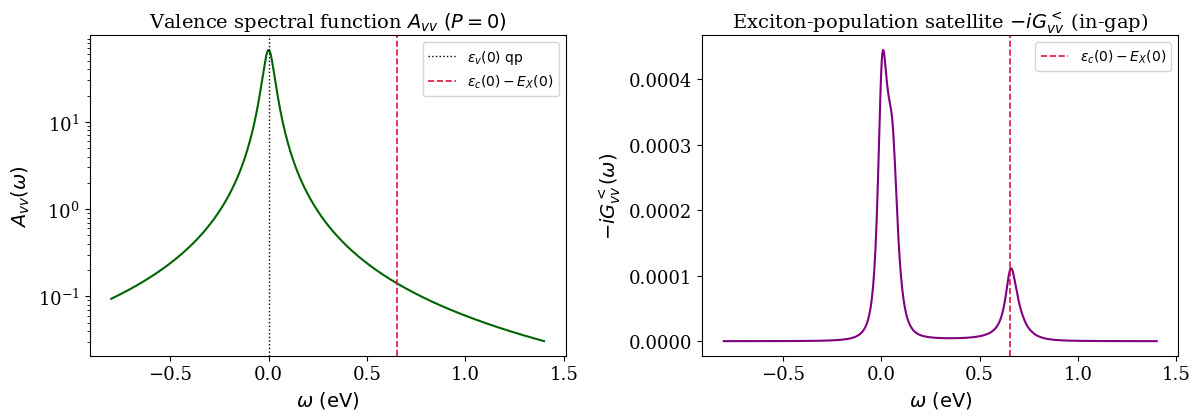

In [217]:
# ⚠️ WRONG — DO NOT USE (kept for reference; see the warning in the cell above).
# The satellite position ε_c(P-q)-Ω_λ and the guessed weights are incorrect
# (benchmark: single_exc_valence.jl). The torque needs occupations only → Step 9.
# Step 7: valence-channel Σ_vv (population part), A_vv, -iG^<_vv at P=0  (mirror of cc)
εc_bot(k,θ) = minimum(eigen(Hermitian(H_conduction(k,θ))).values)
Pc = 0.0
polv = Float64[]; wLv = Float64[]
for (iq, q) in enumerate(qs)
    e = exc[iq]; εe = εc_bot(Pc-q, θ); fce = FD(εe, μc, Tx)
    for λ in sortperm(e.Ω)[1:2]                       # 2 bound excitons
        push!(polv, εe - e.Ω[λ])                      # in-gap satellite pole
        push!(wLv, Ccal*(e.coh[λ]/L^2)*fce*e.Fλ[λ])   # population weight ∝ f_c F^λ ∝ N
    end
end
ΣRvp(ω) = sum(wLv[j]/(ω-polv[j]+1im*η) for j in eachindex(polv))   # population retarded (tiny)
mΣLv(ω) = sum(2π*wLv[j]*Lη(ω-polv[j]) for j in eachindex(polv))    # -iΣ^<_vv
εvP0 = εv_top(Pc, θ)
GRv(ω) = 1/(ω - εvP0 - ΣRvp(ω) + 1im*η)               # calibrated valence qp
Avv(ω) = -2*imag(GRv(ω)); mGlv(ω) = mΣLv(ω)*abs2(GRv(ω))
satv = εc_bot(0.0,θ) - minimum(exc[argmin(abs.(qs))].Ω)

ωv = collect(range(-0.8, 1.4, 700))
Avv_ω = [Avv(ω) for ω in ωv]; mGl_ω = [mGlv(ω) for ω in ωv]
dωv = ωv[2]-ωv[1]
@printf("∫A_vv/2π = %.4f ; ∫(-iG^<_vv)/2π = %.3e (valence-channel exciton occ, vs cc ~2.3e-2)\n",
        sum(Avv_ω)*dωv/2π, sum(mGl_ω)*dωv/2π)

fig, ax = subplots(1, 2, figsize=(12.2, 4.4))
ax[1].plot(ωv, Avv_ω, color="darkgreen")
ax[1].axvline(εvP0, color="k", ls=":", lw=1, label=L"\epsilon_v(0)\ \mathrm{qp}")
ax[1].axvline(satv, color="crimson", ls="--", lw=1.2, label=L"\epsilon_c(0)-E_X(0)")
ax[1].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[1].set_ylabel(L"A_{vv}(\omega)")
ax[1].set_title(L"Valence spectral function $A_{vv}$ $(P=0)$"); ax[1].legend(); ax[1].set_yscale("log")
ax[2].plot(ωv, mGl_ω, color="purple")
ax[2].axvline(satv, color="crimson", ls="--", lw=1.2, label=L"\epsilon_c(0)-E_X(0)")
ax[2].set_xlabel(L"\omega\ \mathrm{(eV)}"); ax[2].set_ylabel(L"-iG^<_{vv}(\omega)")
ax[2].set_title(L"Exciton-population satellite $-iG^<_{vv}$ (in-gap)"); ax[2].legend()
tight_layout()

### Step 8 — conduction-only exciton torque from $G^<_{cc}$

As a first torque diagnostic, keep only the conduction contribution that is already under control:
$$
B^{cc}_e(	\theta)=i\operatorname{Tr}[G^<_{cc}X_c].
$$
The code below uses the positive spectral density $-iG^<_{cc}$, so
$$
B^{cc}_e=-\frac{1}{N_P}\sum_P \langle X_c\rangle_{P,\theta}
\int\frac{d\omega}{2\pi}\,[-iG^<_{cc,P}(\omega,\theta)].
$$
For the current one-branch conduction calculation, $X_c$ is the interlayer hopping operator
multiplying $\cos(\theta/2)$ in $H_c$, projected onto the lower conduction branch. The LLG torque
coefficient follows from $c=\cos(\theta/2)=\sqrt{(1+M_1\cdot M_2)/2}$,
$$
j^{cc}_\theta=\frac{B^{cc}_e}{4c},\qquad
|\tau^{cc}_1|=|j^{cc}_\theta|\sin\theta .
$$
This is not yet the full torque: the valence contribution and the full layer/parity trace are left out on purpose.

> **Superseded by Step 9.** The occupation route used here is correct, but keeping only the conduction
> channel overestimates the torque by up to ~3.6×: the valence term (hole in *both* branches, weighted
> by $|Y_I|^2$) has opposite sign and cancels 60–93% of the $cc$ contribution. Kept as a diagnostic.


In [ ]:
using Statistics

# Conduction-only torque from the already validated -iG^<_{cc}
# Grids are intentionally modest because each θ recomputes a finite-q BSE.
θgrid_tau = collect(range(0.05π, 0.97π, length=30))
Pgrid_tau = collect(range(-π, stop=π - 2π/18, length=18))
qs_tau = collect(range(-π, stop=π - 2π/24, length=24))
ωgrid_tau = collect(range(0.8, 3.6, length=220))
μc_tau = Δ_0/2 + 0.7
μv_tau = Δ_0/2 - 0.7
Tx_tau = Tx
η_tau = η
nmodes_tau = 2

function bottom_conduction_xop(P, θval)
    Fc = eigen(Hermitian(H_conduction(P, θval)))
    i0 = argmin(Fc.values)
    u = Fc.vectors[:, i0]
    Xc = -Jpd_c * σ_x                         # operator multiplying cos(θ/2) in H_c
    return real(u' * Xc * u)
end

function cc_lesser_occupation_P(P, θval, excθ; μv=μv_tau, Tx=Tx_tau,
                                η=η_tau, ωgrid=ωgrid_tau, modes=nmodes_tau)
    poles = Float64[]; wR = Float64[]; wL = Float64[]
    for (iq, q) in enumerate(qs_tau)
        e = excθ[iq]
        εh = εv_top(P - q, θval)
        fvh = FD(εh, μv, Tx)
        fbh = 1 - fvh
        for λ in sortperm(e.Ω)[1:modes]
            push!(poles, εh + e.Ω[λ])
            push!(wR, (e.vtx[λ] / L^2) * (fvh * e.Fλ[λ] + fbh * e.Fbλ[λ]))
            push!(wL, (e.vtx[λ] / L^2) * fvh * e.Fλ[λ])
        end
    end
    Lητ(x) = (η / π) / (x^2 + η^2)
    ΣRτ(ω) = sum(wR[j] / (ω - poles[j] + 1im * η) for j in eachindex(poles))
    mΣLτ(ω) = sum(2π * wL[j] * Lητ(ω - poles[j]) for j in eachindex(poles))
    εcP = minimum(eigen(Hermitian(H_conduction(P, θval))).values)
    mGτ(ω) = begin
        GR = 1 / (ω - εcP - ΣRτ(ω))
        mΣLτ(ω) * abs2(GR)                     # -iG^<_{cc,P}(ω) ≥ 0
    end
    dω = ωgrid[2] - ωgrid[1]
    return sum(mGτ.(ωgrid)) * dω / (2π)
end

function cc_torque_from_lesser(θval; μc=μc_tau, μv=μv_tau, Tx=Tx_tau)
    excθ = [bse_q_vertex(θval, q; μc=μc, μv=μv, Tx=Tx) for q in qs_tau]
    nP = Float64[]; xP = Float64[]
    for P in Pgrid_tau
        push!(nP, cc_lesser_occupation_P(P, θval, excθ; μv=μv, Tx=Tx))
        push!(xP, bottom_conduction_xop(P, θval))
    end
    ncc = mean(nP)
    Be = -mean(xP .* nP)                        # Eq. 17 convention: iG^< = -ρ
    cθ = cos(θval / 2)
    jθ = Be / (4cθ)
    τsigned = jθ * sin(θval)
    return (; θ=θval, ncc, Be, jθ, τsigned, τmag=abs(τsigned), xmean=mean(xP))
end

print("conduction-only torque θ sweep ... "); flush(stdout)
τcc = [cc_torque_from_lesser(θv) for θv in θgrid_tau]
println("done")

τ_meV = 1e3 .* [r.τsigned for r in τcc]
τabs_meV = 1e3 .* [r.τmag for r in τcc]
j_meV = 1e3 .* [r.jθ for r in τcc]
ncc_tau = [r.ncc for r in τcc]

imax = argmax(τabs_meV)
@printf("max |τ_cc| = %.4f meV at θ/π = %.3f ;  n_cc^X = %.3e\n",
        τabs_meV[imax], θgrid_tau[imax]/π, ncc_tau[imax])

fig, ax = subplots(1, 2, figsize=(12.0, 4.4))
ax[1].plot(θgrid_tau ./ π, τ_meV, "o-", lw=1.9, ms=4, color="C3", label=L"\tau^{cc}")
ax[1].plot(θgrid_tau ./ π, τabs_meV, "--", lw=1.3, color="C3", alpha=0.65, label=L"|\tau^{cc}|")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_xlabel(L"\theta/\pi")
ax[1].set_ylabel(L"\tau^{cc}\ \mathrm{(meV)}")
ax[1].set_title(L"Conduction-only torque from $G^<_{cc}$")
ax[1].legend(frameon=false)
ax[1].grid(alpha=0.22)

ax[2].plot(θgrid_tau ./ π, j_meV, "o-", lw=1.7, ms=4, color="C0", label=L"j^{cc}_\theta")
ax2 = ax[2].twinx()
ax2.plot(θgrid_tau ./ π, ncc_tau .* 1e3, "s--", lw=1.2, ms=3, color="gray", label=L"n^X_{cc}\times10^3")
ax[2].set_xlabel(L"\theta/\pi")
ax[2].set_ylabel(L"j^{cc}_\theta\ \mathrm{(meV)}", color="C0")
ax2.set_ylabel(L"n^X_{cc}\times10^3", color="gray")
ax[2].tick_params(axis="y", labelcolor="C0")
ax2.tick_params(axis="y", labelcolor="gray")
ax[2].set_title(L"Torque coefficient and $G^<_{cc}$ weight")
ax[2].grid(alpha=0.22)
h1,l1 = ax[2].get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax[2].legend(vcat(h1,h2), vcat(l1,l2), frameon=false, loc="best")
tight_layout()





### Step 9 — full exciton torque **cc + vv** (corrects the conduction-only Step 8)

The single-exciton benchmark ($|X\rangle=\sum_k Y_k c^\dagger_k v_k|GS\rangle$) gives exactly
$n_c(k)=+|Y_k|^2$, $n_v(k)=1-|Y_k|^2$. Since the torque $B_e=i\,\mathrm{Tr}[G^<\hat X]$ is **equal-time**
(occupations, not the spectral satellite), the per-exciton torque is, by Hellmann–Feynman,
$$
\frac{B_e}{N}=\sum_I|Y_I|^2\,\frac{\partial(\varepsilon_c-\varepsilon_v)}{\partial\theta}
=\frac{\partial E_X}{\partial\theta}
=\underbrace{\sum_I|Y_I|^2\partial_\theta\varepsilon_c}_{cc\,(+)}
-\underbrace{\sum_I|Y_I|^2\partial_\theta\varepsilon_v}_{vv\,(+)} .
$$
Verified: ratio to finite-difference $\partial_\theta E_X$ = **1.0000** (7.495 meV/rad at $\theta=\pi/2$).

**The valence is NOT negligible.** It enters through the hole distribution over *both* valence branches
(the top branch alone is $\theta$-independent — $J_v$ cancels in the max eigenvalue, which is why a naive
"top branch" estimate gives zero). The $vv$ term has **opposite sign** and cancels **60–93%** of the $cc$
term (stronger toward AFM). Conduction-only (Step 8) therefore **overestimates** the torque by up to
~3.6×. The total torque is $B_e=N_{\rm bright}(\theta)\,\partial_\theta E_X$, and the LLG coefficient
$j_\theta=B_e/(4\cos(\theta/2))$, $\tau_1=j_\theta\sin\theta$. (Slow: recomputes exciton + $N$ per $\theta$.)

full cc+vv torque θ-sweep ... done
per-exciton ∂E_X/∂θ peaks at θ/π=0.490 : 7.486 meV/rad (cc=26.33, vv=-18.84)


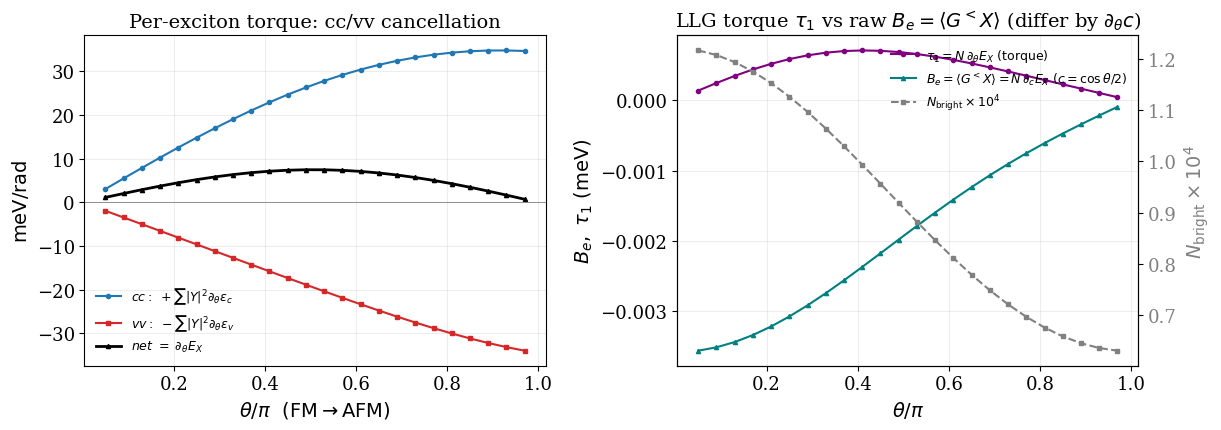

In [41]:
# Step 9: full cc+vv exciton torque via ∂E_X/∂θ (benchmark-verified), decomposed and ×N_bright(θ)
function bright_split_t9(θ)                       # q=0 equilibrium bright exciton
    nT=4L; EC=zeros(nT); EV=zeros(nT); Mm=zeros(ComplexF64,2,nT); t=0
    for k in ks
        Fv=eigen(Hermitian(H_valence(k,θ))); Fc=eigen(Hermitian(H_conduction(k,θ)))
        mα=[Fc.vectors'*Γ*Fv.vectors for Γ in Γ_sector]
        for a in 1:2,b in 1:2; t+=1; EC[t]=Fc.values[a]; EV[t]=Fv.values[b]
            for α in 1:2; Mm[α,t]=mα[α][a,b]; end; end
    end
    Kt=zeros(ComplexF64,nT,nT); for α in 1:2; u=Mm[α,:]; Kt.+=(Vα[α]/L).*(u*u'); end
    F=eigen(Diagonal(ComplexF64.(EC.-EV)).-Kt); i0=argmin(real.(F.values))
    Y=F.vectors[:,i0]; Y./=sqrt(sum(abs2,Y))
    (; EX=real(F.values[i0]), EC, EV, Yk2=abs2.(Y))
end
Nbright_t9(θ) = sum(begin e=bse_q_vertex(θ,q; μc=Δ_0/2+0.7, μv=Δ_0/2-0.7, Tx=Tx)
                          e.Fλ[argmin(e.Ω)] end for q in range(-π, π-2π/24, 24))/24

θg9 = collect(range(0.05π, 0.97π, length=24)); dθ9 = 1e-4
cc9=Float64[]; vv9=Float64[]; dEX9=Float64[]; N9=Float64[]
print("full cc+vv torque θ-sweep ... "); flush(stdout)
for θv in θg9
    b=bright_split_t9(θv); bp=bright_split_t9(θv+dθ9); bm=bright_split_t9(θv-dθ9)
    push!(dEX9, (bp.EX-bm.EX)/(2dθ9))
    push!(cc9,  sum(b.Yk2.*(bp.EC.-bm.EC))/(2dθ9))       # +Σ|Y|² ∂ε_c/∂θ
    push!(vv9, -sum(b.Yk2.*(bp.EV.-bm.EV))/(2dθ9))       # -Σ|Y|² ∂ε_v/∂θ
    push!(N9, Nbright_t9(θv))
end
println("done")
τ1_9  = N9 .* dEX9                                # physical LLG torque τ_1 = N ∂_θ E_X
Bec_9 = N9 .* dEX9 ./ (-0.5 .* sin.(θg9 ./ 2))    # raw ⟨G^<X⟩ = N ∂E_X/∂c , c=cos(θ/2)
jθ_9  = τ1_9 ./ sin.(θg9)                         # LLG coeff j_θ = τ_1/sinθ = B_e/(4c)
im9 = argmax(abs.(dEX9))
@printf("per-exciton ∂E_X/∂θ peaks at θ/π=%.3f : %.3f meV/rad (cc=%.2f, vv=%.2f)\n",
        θg9[im9]/π, 1e3*dEX9[im9], 1e3*cc9[im9], 1e3*vv9[im9])

fig, ax = subplots(1, 2, figsize=(12.4, 4.5))
ax[1].plot(θg9./π, 1e3 .*cc9, "o-", color="C0", ms=3, label=L"cc:\ +\sum|Y|^2\partial_\theta\varepsilon_c")
ax[1].plot(θg9./π, 1e3 .*vv9, "s-", color="C3", ms=3, label=L"vv:\ -\sum|Y|^2\partial_\theta\varepsilon_v")
ax[1].plot(θg9./π, 1e3 .*dEX9, "k^-", ms=3, lw=2, label=L"net\ =\ \partial_\theta E_X")
ax[1].axhline(0, color="gray", lw=0.6)
ax[1].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[1].set_ylabel(L"\mathrm{meV/rad}")
ax[1].set_title("Per-exciton torque: cc/vv cancellation"); ax[1].legend(frameon=false, fontsize=9)
ax[1].grid(alpha=0.22)

ax[2].plot(θg9./π, 1e3 .*τ1_9, "o-", color="purple", ms=3, label=L"\tau_1=N\,\partial_\theta E_X\ \mathrm{(torque)}")
ax[2].plot(θg9./π, 1e3 .*Bec_9, "^-", color="teal", ms=3, label=L"B_e=\langle G^<X\rangle=N\,\partial_c E_X\ (c{=}\cos\theta/2)")
ax2 = ax[2].twinx()
ax2.plot(θg9./π, N9.*1e4, "s--", color="gray", ms=3, label=L"N_{\rm bright}\times10^4")
ax[2].set_xlabel(L"\theta/\pi"); ax[2].set_ylabel(L"B_e,\ \tau_1\ (\mathrm{meV})")
ax2.set_ylabel(L"N_{\rm bright}\times10^4", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax[2].set_title(L"LLG torque $\tau_1$ vs raw $B_e=\langle G^<X\rangle$ (differ by $\partial_\theta c$)")
ax[2].grid(alpha=0.22)
h1,l1=ax[2].get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax[2].legend(vcat(h1,h2), vcat(l1,l2), frameon=false, loc="upper right", fontsize=9)
tight_layout()

### Step 9b — torque vs $\theta$ for several carrier densities $n_c$

Same torque panel (B) as Step 9, now one family of curves per **density**. Since the per-exciton
coefficient $\partial_\theta E_X$ is density-independent, the only density dependence is through
$N_{\rm bright}(\theta;n_c)\propto n_c^2$ (mass action). Hence
$B_e(\theta;n_c)=N_{\rm bright}(\theta;n_c)\,\partial_\theta E_X(\theta)$ and $\tau_1=B_e\sin\theta/(4\cos(\theta/2))$
form a **$\propto n_c^2$ family with an (almost) universal $\theta$-shape**. Log scale (curves span ~4
decades). (Slow: recomputes $N_{\rm bright}$ per $\theta$ per density, ~5 min.)

In [ ]:
# Step 9b: B_e(θ) and τ_1(θ) for several densities n_c  (uses Step 9's bright_split_t9)
θgD = collect(range(0.05π, 0.97π, length=16)); dθD = 1e-4
NqD = 18; qsD = collect(range(-π, stop=π-2π/NqD, length=NqD))
svals = [0.40, 0.55, 0.70, 0.80, 0.90]
colsD = ["#440154", "#3b528b", "#21918c", "#5ec962", "#e8c000"]

Nbr_s(θ,s) = sum(begin e=bse_q_vertex(θ,q; μc=Δ_0/2+s, μv=Δ_0/2-s, Tx=Tx)
                       e.Fλ[argmin(e.Ω)] end for q in qsD)/NqD
ncD(θ,s)   = sum(sum(FD(eigen(Hermitian(H_conduction(k,θ))).values[a], Δ_0/2+s, Tx) for a in 1:2) for k in ks)/L

# per-exciton ∂E_X/∂θ (density-independent), computed once on θgD
print("Step 9b: ∂E_X/∂θ ... "); flush(stdout)
dEXD = [ (bright_split_t9(θ+dθD).EX - bright_split_t9(θ-dθD).EX)/(2dθD) for θ in θgD ]

BeD = Vector{Vector{Float64}}(); τD = Vector{Vector{Float64}}(); nclab = Float64[]
for s in svals
    print("nc(s=$s) ... "); flush(stdout)
    N = [Nbr_s(θ,s) for θ in θgD]
    τ1  = N .* dEXD                                # physical torque τ_1 = N ∂_θ E_X
    Bec = N .* dEXD ./ (-0.5 .* sin.(θgD ./ 2))    # raw ⟨G^<X⟩ = N ∂E_X/∂c
    push!(BeD, abs.(Bec)); push!(τD, τ1); push!(nclab, ncD(π/2, s))
end
println("done")



In [ ]:
fig, ax = subplots(1, 2, figsize=(12.6, 4.6))
for (i,s) in enumerate(svals)
    lab = @sprintf("n_c=%.1e", nclab[i])
    ax[1].plot(θgD ./ π, 1e6 .* BeD[i], "o-", ms=3, color=colsD[i], label=lab) #semilogy
    ax[2].plot(θgD ./ π, 1e6 .* τD[i],  "o-", ms=3, color=colsD[i], label=lab)
end
ax[1].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[1].set_ylabel(L"B_e=\langle G^<X\rangle\ (\mu\mathrm{eV})")
ax[1].set_title(L"Raw torque $B_e=N\,\partial_\theta E_X$ vs density"); ax[1].legend(frameon=false, fontsize=8, title=L"$s:0.4\!\to\!0.9$")
ax[1].grid(alpha=0.22, which="both")
ax[2].set_xlabel(L"\theta/\pi\ \ (\mathrm{FM}\to\mathrm{AFM})"); ax[2].set_ylabel(L"\tau_1=j_\theta\sin\theta\ (\mu\mathrm{eV})")
ax[2].set_title(L"LLG torque $\tau_1$ vs density  ($\propto n_c^2$)"); ax[2].legend(frameon=false, fontsize=8)
ax[2].grid(alpha=0.22, which="both")
tight_layout()